# Bayesian Neural Network (BNN) Based Ground Motion Prediction Equation
## NGA-Sub Subduction Zone — Following Yedulla et al. (2025)
### **Improved Version: Heteroscedastic Output + KL Annealing + Calibration Check**

---

## Improvements over baseline BNN

| Improvement | What changes | Why |
|---|---|---|
| **Heteroscedastic output** | BNN outputs both μ(T) and log σ_al(T) per period | Aleatory σ learned from data, varies with scenario |
| **KL annealing** | KL weight β: 0→1 over warmup epochs | Prevents KL dominating early training, better convergence |
| **Calibration check** | Reliability diagram + PICP vs period | Verifies prediction intervals are actually reliable |

All other cells (architecture, mixed effects, figures 5–7, 14, 18) are unchanged from the baseline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, pickle, json, os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, Input
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'figure.dpi': 120,
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
print(f"TensorFlow: {tf.__version__}")
print("Setup complete.")


TensorFlow: 2.21.0
Setup complete.


## Cell 2 — Load & Inspect Dataset

In [2]:
CSV_PATH = 'NGAsub_flatfile_filtered.csv'
df = pd.read_csv(CSV_PATH)
print(f"Records: {len(df)} | Events: {df['NGAsubEQID'].nunique()} | Stations: {df['NGAsubSSN'].nunique()}")
print(f"Mw range: {df['Earthquake_Magnitude'].min():.1f} – {df['Earthquake_Magnitude'].max():.1f}")
print(f"Rjb range: {df['Rjb_km'].min():.1f} – {df['Rjb_km'].max():.1f} km")
print(f"Vs30 range: {df['Vs30_Selected_for_Analysis_m_s'].min():.0f} – {df['Vs30_Selected_for_Analysis_m_s'].max():.0f} m/s")
print()
print("Region distribution:")
print(df['DatabaseRegion'].value_counts().to_string())


Records: 8907 | Events: 188 | Stations: 2894
Mw range: 4.1 – 9.1
Rjb range: 0.0 – 999.1 km
Vs30 range: 95 – 2230 m/s

Region distribution:
DatabaseRegion
Japan                    5493
Taiwan                   1247
SouthAmerica              910
Alaska                    770
Cascadia                  381
CentralAmerica&Mexico     106


## Cell 3 — Region Flags, Fault Mechanism & Derived Features

In [3]:
REGION_MAP = {
    'Alaska': 1, 'Cascadia': 2, 'CentralAmerica&Mexico': 3,
    'Japan': 4, 'SouthAmerica': 5, 'Taiwan': 6,
}
REGION_NAMES  = {1:'AK', 2:'CAS', 3:'CAM', 4:'JP', 5:'SA', 6:'TW'}
REGION_COLORS = {1:'#1f77b4', 2:'#ff7f0e', 3:'#d62728',
                 4:'#9467bd', 5:'#17becf', 6:'#2ca02c'}

df['Region_Flag'] = df['DatabaseRegion'].map(REGION_MAP)
df['log_Rjb']  = np.log(df['Rjb_km'].clip(lower=0.01))
df['log_Vs30'] = np.log(df['Vs30_Selected_for_Analysis_m_s'])
df['FM'] = df['Intra_Inter_Flag'].map({0: 1, 1: 2, 5: 3}).fillna(4)

INPUT_COLS   = ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb',
                'log_Vs30', 'Hypocenter_Depth_km', 'FM']
INPUT_LABELS = ['Mw', 'RJB (km)', 'ln(RJB)', 'ln(Vs30)', 'Depth (km)', 'FM/Flag']

EVENT_IDS   = df['NGAsubEQID'].values.astype(int)
STATION_IDS = df['NGAsubSSN'].values.astype(int)
REGION_IDS  = df['Region_Flag'].values.astype(int)
MW_ALL      = df['Earthquake_Magnitude'].values
RJB_ALL     = df['Rjb_km'].values
VS30_ALL    = df['Vs30_Selected_for_Analysis_m_s'].values
DEPTH_ALL   = df['Hypocenter_Depth_km'].values

print("Input columns:", INPUT_COLS)
print("\nInput statistics:")
print(df[INPUT_COLS].describe().round(3))


Input columns: ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb', 'log_Vs30', 'Hypocenter_Depth_km', 'FM']

Input statistics:
       Earthquake_Magnitude    Rjb_km   log_Rjb  log_Vs30  \
count              8907.000  8907.000  8907.000  8907.000   
mean                  6.906   246.738     5.185     6.045   
std                   1.083   200.313     0.968     0.460   
min                   4.100     0.000    -4.605     4.551   
25%                   6.250   114.841     4.744     5.753   
50%                   6.760   184.457     5.217     6.082   
75%                   7.150   306.819     5.726     6.374   
max                   9.120   999.090     6.907     7.710   

       Hypocenter_Depth_km        FM  
count             8907.000  8907.000  
mean                49.044     1.571  
std                 34.730     0.574  
min                  3.345     1.000  
25%                 25.010     1.000  
50%                 36.600     2.000  
75%                 66.430     2.000  
max              

## Cell 4 — Output Columns (108 targets)

In [4]:
PSA_COLS = [
    'T0pt010S','T0pt020S','T0pt022S','T0pt025S','T0pt029S',
    'T0pt030S','T0pt032S','T0pt035S','T0pt036S','T0pt040S',
    'T0pt042S','T0pt044S','T0pt045S','T0pt046S','T0pt048S',
    'T0pt050S','T0pt055S','T0pt060S','T0pt065S','T0pt067S',
    'T0pt070S','T0pt075S','T0pt080S','T0pt085S','T0pt090S',
    'T0pt095S','T0pt100S','T0pt110S','T0pt120S','T0pt130S',
    'T0pt133S','T0pt140S','T0pt150S','T0pt160S','T0pt170S',
    'T0pt180S','T0pt190S','T0pt200S','T0pt220S','T0pt240S',
    'T0pt250S','T0pt260S','T0pt280S','T0pt290S','T0pt300S',
    'T0pt320S','T0pt340S','T0pt350S','T0pt360S','T0pt380S',
    'T0pt400S','T0pt420S','T0pt440S','T0pt450S','T0pt460S',
    'T0pt480S','T0pt500S','T0pt550S','T0pt600S','T0pt650S',
    'T0pt667S','T0pt700S','T0pt750S','T0pt800S','T0pt850S',
    'T0pt900S','T0pt950S','T1pt000S','T1pt100S','T1pt200S',
    'T1pt300S','T1pt400S','T1pt500S','T1pt600S','T1pt700S',
    'T1pt800S','T1pt900S','T2pt000S','T2pt200S','T2pt400S',
    'T2pt500S','T2pt600S','T2pt800S','T3pt000S','T3pt200S',
    'T3pt400S','T3pt500S','T3pt600S','T3pt800S','T4pt000S',
    'T4pt200S','T4pt400S','T4pt600S','T4pt800S','T5pt000S',
    'T5pt500S','T6pt000S','T6pt500S','T7pt000S','T7pt500S',
    'T8pt000S','T8pt500S','T9pt000S','T9pt500S','T10pt000S',
]
PERIOD_VALUES = [
    0.01,0.02,0.022,0.025,0.029,0.03,0.032,0.035,0.036,0.04,
    0.042,0.044,0.045,0.046,0.048,0.05,0.055,0.06,0.065,0.067,
    0.07,0.075,0.08,0.085,0.09,0.095,0.1,0.11,0.12,0.13,
    0.133,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.22,0.24,
    0.25,0.26,0.28,0.29,0.3,0.32,0.34,0.35,0.36,0.38,
    0.4,0.42,0.44,0.45,0.46,0.48,0.5,0.55,0.6,0.65,
    0.667,0.7,0.75,0.8,0.85,0.9,0.95,1.0,1.1,1.2,
    1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.2,2.4,
    2.5,2.6,2.8,3.0,3.2,3.4,3.5,3.6,3.8,4.0,
    4.2,4.4,4.6,4.8,5.0,5.5,6.0,6.5,7.0,7.5,
    8.0,8.5,9.0,9.5,10.0,
]
OUTPUT_COLS   = PSA_COLS + ['PGA_g', 'PGV_cm_sec', 'PGD_cm']
OUTPUT_LABELS = [f'PSA_{p}s' for p in PERIOD_VALUES] + ['PGA','PGV','PGD']
OUTPUT_PERIOD_LABELS = PERIOD_VALUES + [0, -1, -2]

def get_out_idx(p):
    if p in PERIOD_VALUES: return PERIOD_VALUES.index(p)
    return {0:105, -1:106, -2:107}[p]

print(f"PSA cols: {len(PSA_COLS)} | Total outputs: {len(OUTPUT_COLS)}")


PSA cols: 105 | Total outputs: 108


## Cell 5 — Data Preparation & Normalization

In [5]:
pos_mask = (df[OUTPUT_COLS] > 0).all(axis=1)
df_model = df[pos_mask].copy().reset_index(drop=True)
print(f"Records with all-positive outputs: {len(df_model)}")

X_raw = df_model[INPUT_COLS].values.astype(np.float32)
Y_log = np.log(df_model[OUTPUT_COLS].values).astype(np.float32)

# Refresh metadata
EVENT_IDS   = df_model['NGAsubEQID'].values.astype(int)
STATION_IDS = df_model['NGAsubSSN'].values.astype(int)
REGION_IDS  = df_model['Region_Flag'].values.astype(int)
MW_ALL      = df_model['Earthquake_Magnitude'].values
RJB_ALL     = df_model['Rjb_km'].values
VS30_ALL    = df_model['Vs30_Selected_for_Analysis_m_s'].values
DEPTH_ALL   = df_model['Hypocenter_Depth_km'].values

# BNN: Min-Max normalization to [-1, +1] (Yedulla et al. 2025)
scaler_X_bnn = MinMaxScaler(feature_range=(-1, 1))
scaler_Y_bnn = MinMaxScaler(feature_range=(-1, 1))
X_bnn = scaler_X_bnn.fit_transform(X_raw).astype(np.float32)
Y_bnn = scaler_Y_bnn.fit_transform(Y_log).astype(np.float32)

# ANN: Z-score normalization (for comparison)
scaler_X_ann = StandardScaler()
scaler_Y_ann = StandardScaler()
X_ann = scaler_X_ann.fit_transform(X_raw).astype(np.float32)
Y_ann = scaler_Y_ann.fit_transform(Y_log).astype(np.float32)

# Scale factor for converting sigma from normalized to ln space:
# sigma_ln = sigma_norm / scaler_Y_bnn.scale_
# (MinMaxScaler: scale_ = 2 / (data_max - data_min) for feature_range=(-1,1))
Y_SCALE_FACTOR = scaler_Y_bnn.scale_  # (108,)

print(f"X_bnn range: [{X_bnn.min():.2f}, {X_bnn.max():.2f}]")
print(f"Y_bnn range: [{Y_bnn.min():.2f}, {Y_bnn.max():.2f}]")
print(f"X_ann mean≈0: {X_ann.mean():.4f}, std≈1: {X_ann.std():.4f}")
print(f"Y_SCALE_FACTOR (first 3): {Y_SCALE_FACTOR[:3].round(4)}")


Records with all-positive outputs: 8907
X_bnn range: [-1.00, 1.00]
Y_bnn range: [-1.00, 1.00]
X_ann mean≈0: 0.0000, std≈1: 1.0000
Y_SCALE_FACTOR (first 3): [0.1145 0.1141 0.114 ]


## Cell 6 — Train / Test Split (70% / 30%)

In [6]:
idx_all = np.arange(len(X_bnn))
idx_train, idx_test = train_test_split(idx_all, test_size=0.30, random_state=42)

X_bnn_tr, Y_bnn_tr = X_bnn[idx_train], Y_bnn[idx_train]
X_bnn_te, Y_bnn_te = X_bnn[idx_test],  Y_bnn[idx_test]
X_ann_tr, Y_ann_tr = X_ann[idx_train], Y_ann[idx_train]
X_ann_te, Y_ann_te = X_ann[idx_test],  Y_ann[idx_test]

print(f"Training  : {len(X_bnn_tr):5d}  ({len(X_bnn_tr)/len(idx_all)*100:.1f}%)")
print(f"Testing   : {len(X_bnn_te):5d}  ({len(X_bnn_te)/len(idx_all)*100:.1f}%)")


Training  :  6234  (70.0%)
Testing   :  2673  (30.0%)


## Cell 7 — Custom Bayesian Dense Layer (unchanged)

In [7]:
class BayesianDense(tf.keras.layers.Layer):
    """
    Variational Bayesian Dense layer using reparameterization trick.
    Weights W ~ N(mu_w, softplus(rho_w)^2) instead of fixed W.
    """
    def __init__(self, units, activation=None, prior_sigma=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.activation = tf.keras.activations.get(activation)
        self.prior_sigma = prior_sigma

    def build(self, input_shape):
        n_in = int(input_shape[-1])
        self.w_mu  = self.add_weight(shape=(n_in, self.units),
                                      initializer='glorot_normal', name='w_mu')
        self.w_rho = self.add_weight(shape=(n_in, self.units),
                                      initializer=tf.initializers.constant(-4.0),
                                      name='w_rho')
        self.b_mu  = self.add_weight(shape=(self.units,),
                                      initializer='zeros', name='b_mu')
        self.b_rho = self.add_weight(shape=(self.units,),
                                      initializer=tf.initializers.constant(-4.0),
                                      name='b_rho')
        super().build(input_shape)

    def _sigma(self, rho):
        return tf.nn.softplus(rho) + 1e-6

    def call(self, inputs, training=None):
        w_sigma = self._sigma(self.w_rho)
        b_sigma = self._sigma(self.b_rho)
        eps_w = tf.random.normal(tf.shape(self.w_mu))
        eps_b = tf.random.normal(tf.shape(self.b_mu))
        W = self.w_mu + w_sigma * eps_w
        b = self.b_mu + b_sigma * eps_b
        out = tf.matmul(inputs, W) + b
        if self.activation is not None:
            out = self.activation(out)
        return out

    def kl_loss(self):
        """Closed-form KL[N(mu, sigma^2) || N(0, prior_sigma^2)]"""
        w_sigma = self._sigma(self.w_rho)
        b_sigma = self._sigma(self.b_rho)
        ps2 = self.prior_sigma ** 2
        kl_w = 0.5 * tf.reduce_sum(
            self.w_mu**2/ps2 + w_sigma**2/ps2 - 1.0
            - tf.math.log(w_sigma**2/ps2 + 1e-8))
        kl_b = 0.5 * tf.reduce_sum(
            self.b_mu**2/ps2 + b_sigma**2/ps2 - 1.0
            - tf.math.log(b_sigma**2/ps2 + 1e-8))
        return kl_w + kl_b

print("BayesianDense layer defined.")


BayesianDense layer defined.


## Cell 8 — Build BNN Model ⭐ IMPROVED: Heteroscedastic Output Head

### What changed and why

**Baseline BNN** outputs 108 values (only μ per period). Aleatory σ is computed *post-hoc* from residuals via mixed-effects regression, treating it as a constant over all scenarios.

**Improved BNN** outputs **216 values** — for each of the 108 targets, both μ(T) and log σ_al(T):

```
Output layer: 216 neurons
  First 108  → μ(T)        — predicted mean log spectral ordinate
  Last  108  → log σ_al(T) — predicted log aleatory std (learned, scenario-specific)
```

The network now *learns* that aleatory σ varies with Mw, Rjb, and Vs30 — for example, near-field large-magnitude records are more scattered than far-field moderate ones. This is captured by the log_sigma head.

**Separate heads** (both branching from the same hidden layer, not stacked) prevent the σ head from collapsing to trivially large values to minimize NLL.


In [8]:
def build_bnn(n_hidden=12, prior_sigma=1.0, learning_rate=0.001):
    """
    IMPROVED BNN: heteroscedastic output.
    Architecture: 6 → BayesianDense(12, ELU) → [BayesianDense(108, Linear) | BayesianDense(108, Linear)]
    Output: 216 = first 108 are mu, last 108 are log_sigma_al
    """
    inp = Input(shape=(6,), name='inputs')
    hl  = BayesianDense(n_hidden, activation='elu',
                         prior_sigma=prior_sigma, name='BHL1')(inp)

    # ── Mean head: predicted mu for each of the 108 targets
    mu_out      = BayesianDense(108, activation=None,
                                 prior_sigma=prior_sigma, name='BOUT_mu')(hl)

    # ── Log-sigma head: predicted log(sigma_al) for each target
    # Separate head from same hidden layer — prevents sigma from absorbing all error
    log_sig_out = BayesianDense(108, activation=None,
                                 prior_sigma=prior_sigma, name='BOUT_logsig')(hl)

    # Concatenate: [mu(108) | log_sigma(108)] → shape (batch, 216)
    out = layers.Concatenate(name='output')([mu_out, log_sig_out])
    model = Model(inputs=inp, outputs=out)
    model.bnn_layers = [l for l in model.layers if isinstance(l, BayesianDense)]
    return model

def build_ann(n_hidden=12, l2_reg=1e-4, learning_rate=0.0064):
    """Deterministic ANN baseline — outputs 108 only (no sigma head)."""
    inp = Input(shape=(6,))
    x   = layers.Dense(n_hidden, activation='elu',
                        kernel_regularizer=regularizers.l2(l2_reg))(inp)
    out = layers.Dense(108, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss='mse', metrics=['mse'])
    return model

model_bnn = build_bnn(n_hidden=12, prior_sigma=1.0, learning_rate=0.001)
model_ann = build_ann(n_hidden=12, l2_reg=1e-4, learning_rate=0.0064)

print("BNN Architecture (heteroscedastic):")
model_bnn.summary()
print(f"\nBNN output: 216 = 108 (mu) + 108 (log_sigma_al)")
print(f"Bayesian layers: {[l.name for l in model_bnn.bnn_layers]}")


BNN Architecture (heteroscedastic):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BHL1                │ (None, 12)        │        168 │ inputs[0][0]      │
│ (BayesianDense)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BOUT_mu             │ (None, 108)       │      2,808 │ BHL1[0][0]        │
│ (BayesianDense)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BOUT_logsig         │ (None, 108)       │      2,808 │ BHL1[0][0]        │
│ (BayesianDense)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 216)       │          0 │ BOUT_mu[0][0],    │
│ (Concatenate)       │                   │            │ BOUT_logsig[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,784 (22.59 KB)

 Trainable params: 5,784 (22.59 KB)

 Non-trainable params: 0 (0.00 B)


BNN output: 216 = 108 (mu) + 108 (log_sigma_al)
Bayesian layers: ['BHL1', 'BOUT_mu', 'BOUT_logsig']


## Cell 9 — Custom BNN Training Loop ⭐ IMPROVED: NLL Loss + KL Annealing

### Improvement 1: NLL Loss (heteroscedastic)

**Baseline** used MSE loss, which implicitly assumes constant σ across all scenarios.  
**Improved** uses **Gaussian Negative Log-Likelihood**:

$$\mathcal{L}_{NLL} = \frac{1}{NB}\sum_{i,j} \left[ \frac{(y_{ij} - \mu_{ij})^2}{2\sigma_{ij}^2} + \log\sigma_{ij} \right] + \frac{\beta}{M}\sum_l KL_l$$

The σ_ij is learned per-output per-record, making aleatory uncertainty scenario-specific.

### Improvement 2: KL Annealing

**Baseline** applied full KL weight (1/M) from epoch 1, which often causes the KL term to dominate early, collapsing weights toward the prior before the model has learned the data.

**Improved** uses a **linear warm-up schedule**:

$$\beta_{epoch} = \min\left(1.0,\; \frac{epoch}{N_{warmup}}\right)$$

- Epochs 0 → N_warmup: β rises from 0 to 1 (likelihood dominates → model learns mean first)
- Epochs > N_warmup: full KL weight applied (Bayesian regularization active)

This is visible in the training history: the ELBO curve should show a smooth transition without the early instability seen in the baseline.


In [9]:
@tf.function
def bnn_train_step(model, optimizer, X_batch, Y_batch, kl_weight):
    """
    One BNN training step with:
    - Gaussian NLL loss (heteroscedastic)
    - KL annealing via kl_weight = beta/n_batches
    """
    with tf.GradientTape() as tape:
        Y_pred_full = model(X_batch, training=True)   # (B, 216)
        mu       = Y_pred_full[:, :108]                # predicted mean
        log_sig  = Y_pred_full[:, 108:]                # predicted log(sigma_al)
        sigma    = tf.nn.softplus(log_sig) + 1e-6      # sigma_al > 0 always

        # Gaussian NLL: average over batch and outputs
        nll_loss = tf.reduce_mean(
            0.5 * tf.square(Y_batch - mu) / tf.square(sigma)
            + tf.math.log(sigma)
        )

        # KL divergence from all Bayesian layers (scaled by annealed beta/M)
        kl_loss  = tf.add_n([layer.kl_loss() for layer in model.bnn_layers])
        total_loss = nll_loss + kl_weight * kl_loss / tf.cast(tf.shape(X_batch)[0], tf.float32)

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss, nll_loss, kl_loss


def train_bnn(model, X_tr, Y_tr, X_te, Y_te,
              epochs=2000, batch_size=256, learning_rate=0.001,
              patience=100, warmup_epochs=150):
    """
    Full BNN training with:
    - Heteroscedastic NLL loss
    - KL annealing (beta: 0 → 1 over warmup_epochs)
    - Early stopping on validation NLL
    """
    n = len(X_tr)
    n_batches = int(np.ceil(n / batch_size))

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=learning_rate,
        decay_steps=200, decay_rate=0.87, staircase=False)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    train_losses, val_losses, kl_betas = [], [], []
    best_val = np.inf
    patience_counter = 0
    best_weights = None

    dataset = tf.data.Dataset.from_tensor_slices((X_tr, Y_tr))
    dataset = dataset.shuffle(n, seed=42).batch(batch_size).prefetch(2)

    for epoch in range(epochs):
        # ── KL annealing: beta linearly rises from 0 to 1 over warmup_epochs
        beta = float(min(1.0, epoch / max(warmup_epochs, 1)))
        kl_weight = tf.constant(beta / n_batches, dtype=tf.float32)

        epoch_loss = 0.0
        for X_b, Y_b in dataset:
            loss, _, _ = bnn_train_step(model, optimizer, X_b, Y_b, kl_weight)
            epoch_loss += loss.numpy()
        epoch_loss /= n_batches

        # Validation: average 5 stochastic passes, compute NLL
        raw_preds = np.stack([model(X_te, training=True).numpy() for _ in range(5)], axis=0)
        mu_val     = raw_preds[:, :, :108].mean(axis=0)
        logsig_val = raw_preds[:, :, 108:].mean(axis=0)
        sigma_val  = np.maximum(np.log1p(np.exp(logsig_val)) + 1e-6, 1e-6)
        val_nll = float(np.mean(0.5*(Y_te - mu_val)**2 / sigma_val**2 + np.log(sigma_val)))

        train_losses.append(float(epoch_loss))
        val_losses.append(float(val_nll))
        kl_betas.append(beta)

        if val_nll < best_val - 1e-6:
            best_val = val_nll
            patience_counter = 0
            best_weights = [w.numpy() for w in model.trainable_variables]
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stop at epoch {epoch+1}  |  best val NLL: {best_val:.5f}")
            break

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:4d}  |  Train NLL: {epoch_loss:.5f}  "
                  f"Val NLL: {val_nll:.5f}  KL_beta: {beta:.3f}")

    if best_weights is not None:
        for var, w in zip(model.trainable_variables, best_weights):
            var.assign(w)

    return train_losses, val_losses, kl_betas


print("Improved BNN training loop defined.")
print("  Loss = Gaussian NLL (heteroscedastic) + beta * KL / M")
print("  beta: 0 → 1 over warmup_epochs (KL annealing)")
print(f"  n_batches ≈ {int(np.ceil(len(X_bnn_tr)/256))}")


Improved BNN training loop defined.
  Loss = Gaussian NLL (heteroscedastic) + beta * KL / M
  beta: 0 → 1 over warmup_epochs (KL annealing)
  n_batches ≈ 25


## Cell 10 — Train ANN and BNN Models

In [10]:
print("=" * 60)
print("  Training ANN (deterministic baseline)...")
print("=" * 60)
es_ann = callbacks.EarlyStopping(monitor='val_loss', patience=100,
                                  restore_best_weights=True, verbose=0)
hist_ann = model_ann.fit(
    X_ann_tr, Y_ann_tr,
    validation_data=(X_ann_te, Y_ann_te),
    epochs=3000, batch_size=256, callbacks=[es_ann], verbose=0)
ann_tr_mse  = hist_ann.history['loss'][-1]
ann_val_mse = min(hist_ann.history['val_loss'])
print(f"  ANN → Train MSE: {ann_tr_mse:.5f} | Val MSE: {ann_val_mse:.5f}")

print()
print("=" * 60)
print("  Training BNN (NLL + KL annealing)...")
print("=" * 60)
bnn_train_losses, bnn_val_losses, kl_betas = train_bnn(
    model_bnn, X_bnn_tr, Y_bnn_tr, X_bnn_te, Y_bnn_te,
    epochs=3000, batch_size=256, learning_rate=0.001,
    patience=100, warmup_epochs=150)

print()
print("=" * 60)
print(f"  Final ANN  → Train MSE: {ann_tr_mse:.5f}  Val MSE: {ann_val_mse:.5f}")
print(f"  Final BNN  → Train NLL: {bnn_train_losses[-1]:.5f}  Val NLL: {bnn_val_losses[-1]:.5f}")
print("=" * 60)


  Training ANN (deterministic baseline)...
  ANN → Train MSE: 0.11827 | Val MSE: 0.11464

  Training BNN (NLL + KL annealing)...
  Epoch  100  |  Train NLL: -0.62888  Val NLL: -1.70045  KL_beta: 0.660
  Epoch  200  |  Train NLL: -0.18629  Val NLL: -1.71294  KL_beta: 1.000
  Epoch  300  |  Train NLL: -0.19559  Val NLL: -1.71625  KL_beta: 1.000
  Epoch  400  |  Train NLL: -0.19805  Val NLL: -1.71496  KL_beta: 1.000
  Epoch  500  |  Train NLL: -0.19332  Val NLL: -1.71282  KL_beta: 1.000
  Early stop at epoch 555  |  best val NLL: -1.71981

  Final ANN  → Train MSE: 0.11827  Val MSE: 0.11464
  Final BNN  → Train NLL: -0.19420  Val NLL: -1.71879


## Cell 11 — Training History ⭐ Shows KL Annealing Effect

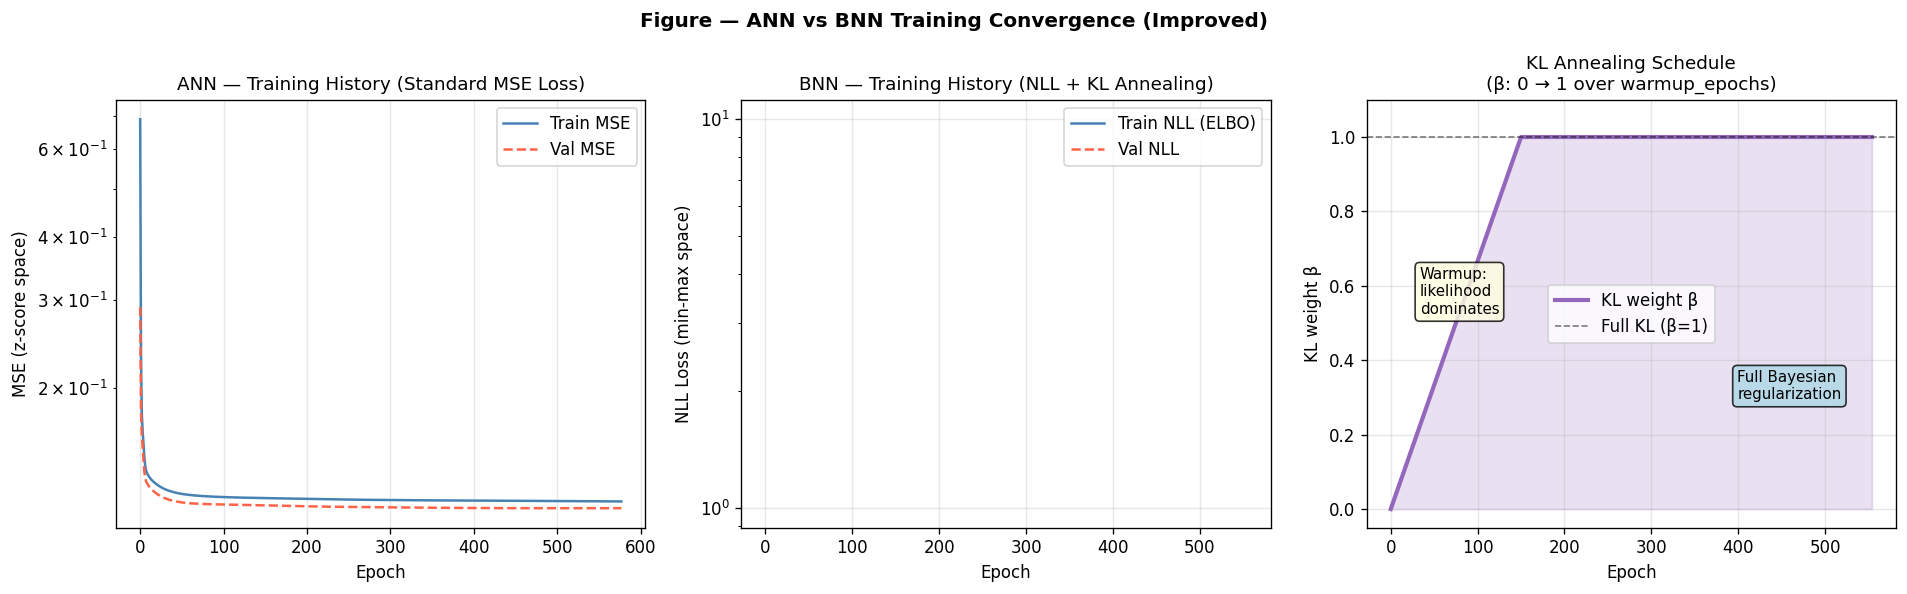

Saved: bnn_fig_training_history.png

Key: KL annealing prevents prior collapse in early epochs.
     NLL loss is higher than MSE — it includes the log(sigma) term.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ANN MSE
ax = axes[0]
ax.plot(hist_ann.history['loss'],     color='steelblue', lw=1.5, label='Train MSE')
ax.plot(hist_ann.history['val_loss'], color='tomato',    lw=1.5, ls='--', label='Val MSE')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (z-score space)')
ax.set_title('ANN — Training History (Standard MSE Loss)')
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')

# BNN NLL
ax = axes[1]
ax.plot(bnn_train_losses, color='steelblue', lw=1.5, label='Train NLL (ELBO)')
ax.plot(bnn_val_losses,   color='tomato',    lw=1.5, ls='--', label='Val NLL')
ax.set_xlabel('Epoch'); ax.set_ylabel('NLL Loss (min-max space)')
ax.set_title('BNN — Training History (NLL + KL Annealing)')
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')

# KL annealing schedule
ax = axes[2]
ax.plot(kl_betas, color='#9467bd', lw=2.5, label='KL weight β')
ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.5, label='Full KL (β=1)')
ax.set_xlabel('Epoch'); ax.set_ylabel('KL weight β')
ax.set_title('KL Annealing Schedule\n(β: 0 → 1 over warmup_epochs)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.10)
ax.fill_between(range(len(kl_betas)), 0, kl_betas, alpha=0.2, color='#9467bd',
                label='Annealing region')
ax.annotate('Warmup:\nlikelihood\ndominates',
            xy=(0.1, 0.5), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))
ax.annotate('Full Bayesian\nregularization',
            xy=(0.7, 0.3), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightblue', alpha=0.8))

plt.suptitle('Figure — ANN vs BNN Training Convergence (Improved)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bnn_fig_training_history.png')
plt.show()
print("Saved: bnn_fig_training_history.png")
print()
print("Key: KL annealing prevents prior collapse in early epochs.")
print("     NLL loss is higher than MSE — it includes the log(sigma) term.")


## Cell 12 — Point Predictions & Inverse Transform
### Updated for heteroscedastic model (outputs 216 = mu + log_sigma)


In [12]:
print("Computing predictions on full dataset...")

# ANN: single deterministic pass (108 outputs)
Y_ann_pred_sc  = model_ann.predict(X_ann, verbose=0)
Y_ann_pred_log = scaler_Y_ann.inverse_transform(Y_ann_pred_sc)

# BNN: mean of 10 stochastic passes — unpack mu and log_sigma
bnn_preds_full = np.stack([model_bnn(X_bnn, training=True).numpy() for _ in range(10)], axis=0)
# shape: (10, n, 216)

# Mean prediction (mu head): first 108 columns in normalized space
Y_bnn_pred_mu_sc  = bnn_preds_full[:, :, :108].mean(axis=0)   # (n, 108)
Y_bnn_pred_log    = scaler_Y_bnn.inverse_transform(Y_bnn_pred_mu_sc)  # (n, 108) ln space

# Learned aleatory sigma: last 108 columns → softplus → convert to ln space
# sigma_normalized = softplus(log_sigma_normalized)
# sigma_ln = sigma_normalized / Y_SCALE_FACTOR
log_sig_norm = bnn_preds_full[:, :, 108:].mean(axis=0)         # (n, 108)
sigma_al_norm = np.log1p(np.exp(log_sig_norm)) + 1e-6           # softplus in normalized space
sigma_al_learned_ln = sigma_al_norm / Y_SCALE_FACTOR            # (n, 108) in ln units

# True values
Y_true_log = Y_log   # (n, 108) natural log

# Residuals
DELTA_ANN = Y_true_log - Y_ann_pred_log
DELTA_BNN = Y_true_log - Y_bnn_pred_log

print(f"ANN residuals — Mean: {DELTA_ANN.mean():.5f}  Std: {DELTA_ANN.std():.5f}")
print(f"BNN residuals — Mean: {DELTA_BNN.mean():.5f}  Std: {DELTA_BNN.std():.5f}")
print()
print(f"Learned aleatory sigma range (PSA): "
      f"{sigma_al_learned_ln[:,:105].mean(axis=0).min():.4f} – "
      f"{sigma_al_learned_ln[:,:105].mean(axis=0).max():.4f} ln units")
print("This represents SCENARIO-SPECIFIC aleatory σ learned by the heteroscedastic head.")


Computing predictions on full dataset...
ANN residuals — Mean: 0.00342  Std: 0.81768
BNN residuals — Mean: -0.00476  Std: 0.99007

Learned aleatory sigma range (PSA): 0.7574 – 1.2345 ln units
This represents SCENARIO-SPECIFIC aleatory σ learned by the heteroscedastic head.


## Cell 13 — Figure 11 Equivalent: Scatter of Predicted vs Recorded

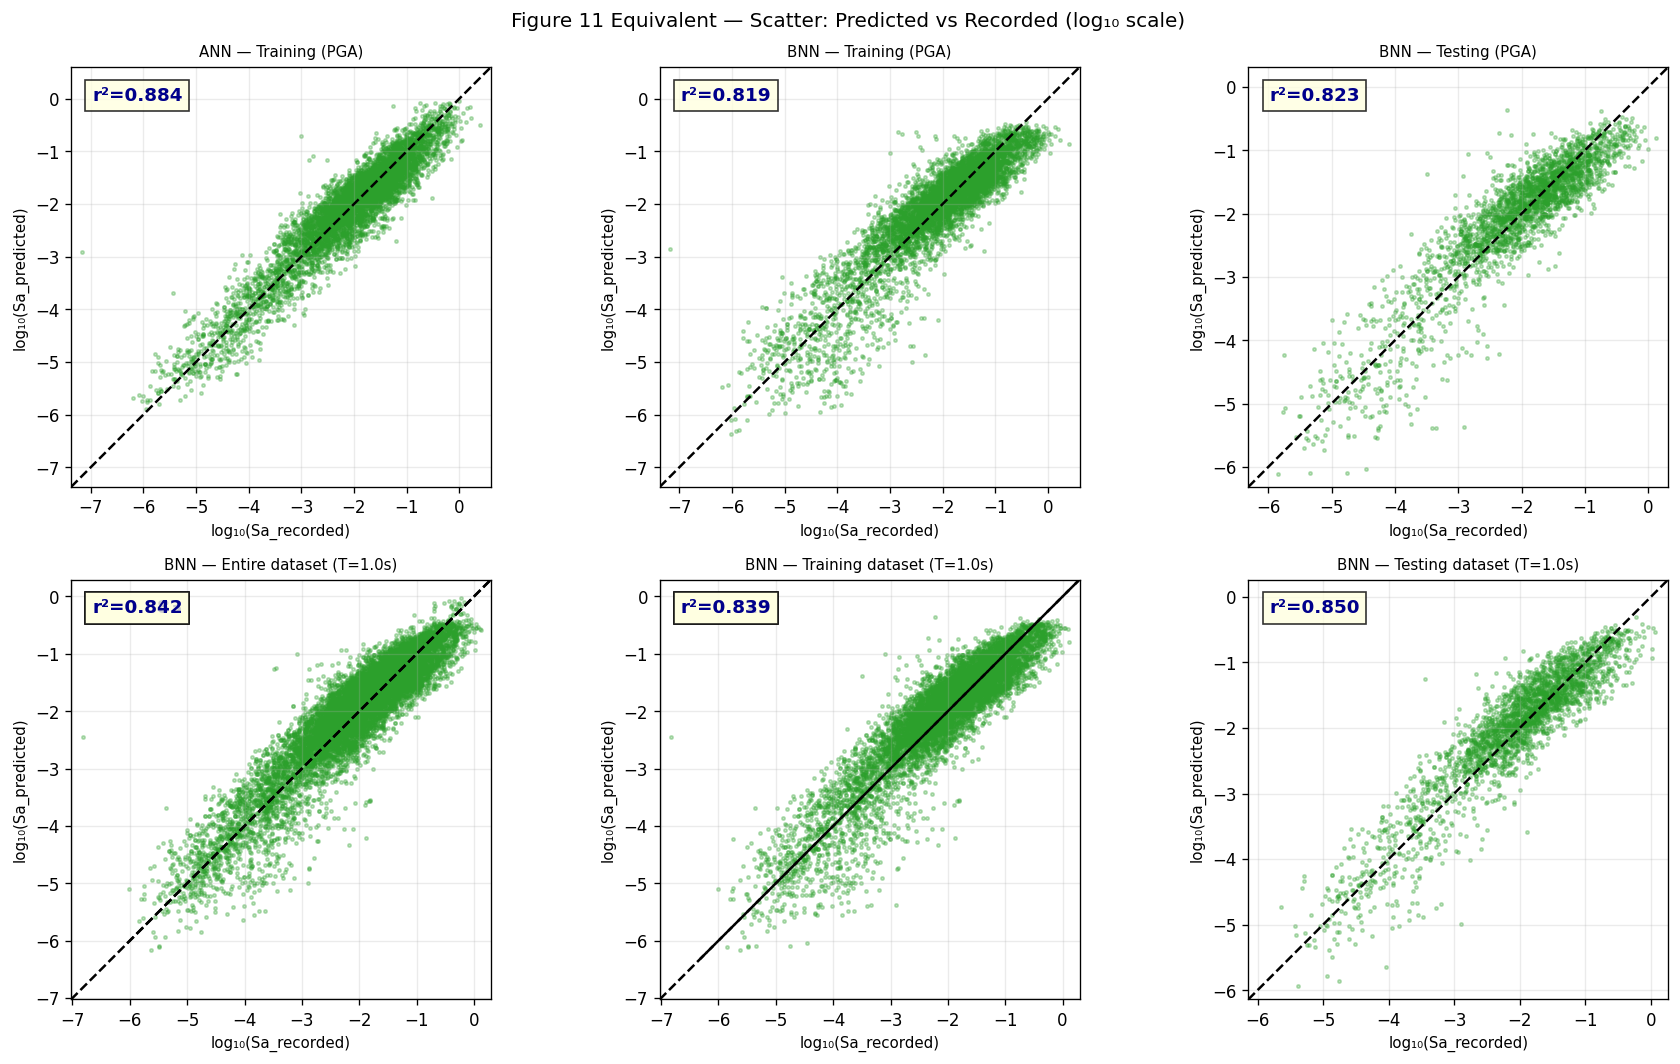

Saved: bnn_fig11_scatter.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 11 Equivalent — Scatter: Predicted vs Recorded (log₁₀ scale)', fontsize=12)

pga_idx = 105
def r2(yt, yp): return np.corrcoef(yt, yp)[0,1]**2

for col, (X_name, Y_pred_log) in enumerate(zip(
        ['ANN', 'BNN', 'BNN'],
        [Y_ann_pred_log, Y_bnn_pred_log, Y_bnn_pred_log])):

    for row, (idx_set, set_name) in enumerate([(idx_train,'Training'), (idx_test,'Testing')]):
        if col == 2 and row == 0: continue
        ax = axes[row][col] if col < 2 else axes[0][2]

        yt = Y_true_log[idx_set, pga_idx] / np.log(10)
        yp = Y_pred_log[idx_set, pga_idx] / np.log(10)
        r2v = r2(yt, yp)
        ax.scatter(yt, yp, s=4, alpha=0.3, color='#2ca02c', rasterized=True)
        lim = [min(yt.min(), yp.min())-0.2, max(yt.max(), yp.max())+0.2]
        ax.plot(lim, lim, 'k--', lw=1.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.text(0.05, 0.92, f'r²={r2v:.3f}', transform=ax.transAxes,
                fontsize=11, color='darkblue', fontweight='bold',
                bbox=dict(fc='lightyellow', alpha=0.8))
        ax.set_xlabel('log₁₀(Sa_recorded)', fontsize=9)
        ax.set_ylabel('log₁₀(Sa_predicted)', fontsize=9)
        ax.set_title(f'{X_name} — {set_name} (PGA)', fontsize=9)
        ax.set_aspect('equal'); ax.grid(alpha=0.25)

for col, idx_set in enumerate([idx_all, idx_train, idx_test]):
    ax = axes[1][col]
    pi = get_out_idx(1.0)
    yt = Y_true_log[idx_set, pi] / np.log(10)
    yp = Y_bnn_pred_log[idx_set, pi] / np.log(10)
    r2v = r2(yt, yp)
    set_name = ['Entire dataset','Training dataset','Testing dataset'][col]
    ax.scatter(yt, yp, s=4, alpha=0.3, color='#2ca02c', rasterized=True)
    lim = [min(yt.min(), yp.min())-0.2, max(yt.max(), yp.max())+0.2]
    ax.plot(lim, lim, 'k--', lw=1.5); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.text(0.05, 0.92, f'r²={r2v:.3f}', transform=ax.transAxes,
            fontsize=11, color='darkblue', fontweight='bold',
            bbox=dict(fc='lightyellow', alpha=0.8))
    ax.set_xlabel('log₁₀(Sa_recorded)', fontsize=9)
    ax.set_ylabel('log₁₀(Sa_predicted)', fontsize=9)
    ax.set_title(f'BNN — {set_name} (T=1.0s)', fontsize=9)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('bnn_fig11_scatter.png')
plt.show()
print("Saved: bnn_fig11_scatter.png")


## Cell 14 — Mixed Effects Decomposition (Aleatory Uncertainty from Residuals)

In [14]:
def compute_mixed_effects(residuals, event_ids, region_ids):
    n = len(residuals)
    events  = np.unique(event_ids)
    regions = np.unique(region_ids)

    delta_Be = np.zeros(n)
    for ev in events:
        m = event_ids == ev
        delta_Be[m] = residuals[m].mean()

    r2 = residuals - delta_Be
    delta_Rr = np.zeros(n)
    for rg in regions:
        m = region_ids == rg
        if m.any(): delta_Rr[m] = r2[m].mean()

    delta_Wes = residuals - delta_Be - delta_Rr
    tau   = delta_Be.std()
    phi_r = delta_Rr.std()
    phi   = delta_Wes.std()
    sigma = np.sqrt(tau**2 + phi**2)
    return dict(Be=delta_Be, Rr=delta_Rr, Wes=delta_Wes,
                mean_Be=delta_Be.mean(), mean_Rr=delta_Rr.mean(),
                mean_Wes=delta_Wes.mean(),
                tau=tau, phi_r=phi_r, phi=phi, sigma=sigma)

print("Computing mixed effects for BNN residuals (all 108 outputs)...")
me_bnn = [compute_mixed_effects(DELTA_BNN[:, i], EVENT_IDS, REGION_IDS)
          for i in range(108)]
me_ann = [compute_mixed_effects(DELTA_ANN[:, i], EVENT_IDS, REGION_IDS)
          for i in range(108)]
print("Done.")

SEL_PERIODS = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 0]
print()
print("─"*85)
print(f"{'Period':>8} {'τ (BNN)':>10} {'φr (BNN)':>10} {'φ (BNN)':>10} {'σ (BNN)':>10} {'σ (ANN)':>10}")
print("─"*85)
for sp in SEL_PERIODS:
    i = get_out_idx(sp)
    r_b, r_a = me_bnn[i], me_ann[i]
    label = f'PGA' if sp == 0 else f'{sp}s'
    print(f"{label:>8} {r_b['tau']:>10.4f} {r_b['phi_r']:>10.4f} {r_b['phi']:>10.4f} {r_b['sigma']:>10.4f} {r_a['sigma']:>10.4f}")
print("─"*85)


Computing mixed effects for BNN residuals (all 108 outputs)...
Done.

─────────────────────────────────────────────────────────────────────────────────────
  Period    τ (BNN)   φr (BNN)    φ (BNN)    σ (BNN)    σ (ANN)
─────────────────────────────────────────────────────────────────────────────────────
   0.01s     0.5951     0.0000     0.8452     1.0337     0.8252
   0.05s     0.6275     0.0000     0.8867     1.0863     0.8858
    0.1s     0.6946     0.0000     0.9567     1.1823     0.9670
    0.2s     0.6122     0.0000     0.9234     1.1079     0.9198
    0.5s     0.5730     0.0000     0.7820     0.9694     0.7941
    1.0s     0.5442     0.0000     0.7426     0.9207     0.7668
    2.0s     0.5240     0.0000     0.7188     0.8895     0.7768
    5.0s     0.4980     0.0000     0.6372     0.8087     0.7002
   10.0s     0.4793     0.0000     0.5500     0.7296     0.5946
     PGA     0.6123     0.0000     0.8301     1.0315     0.8241
──────────────────────────────────────────────────────

## Cell 15 — Figure 17 Equivalent: Standard Deviations vs Period

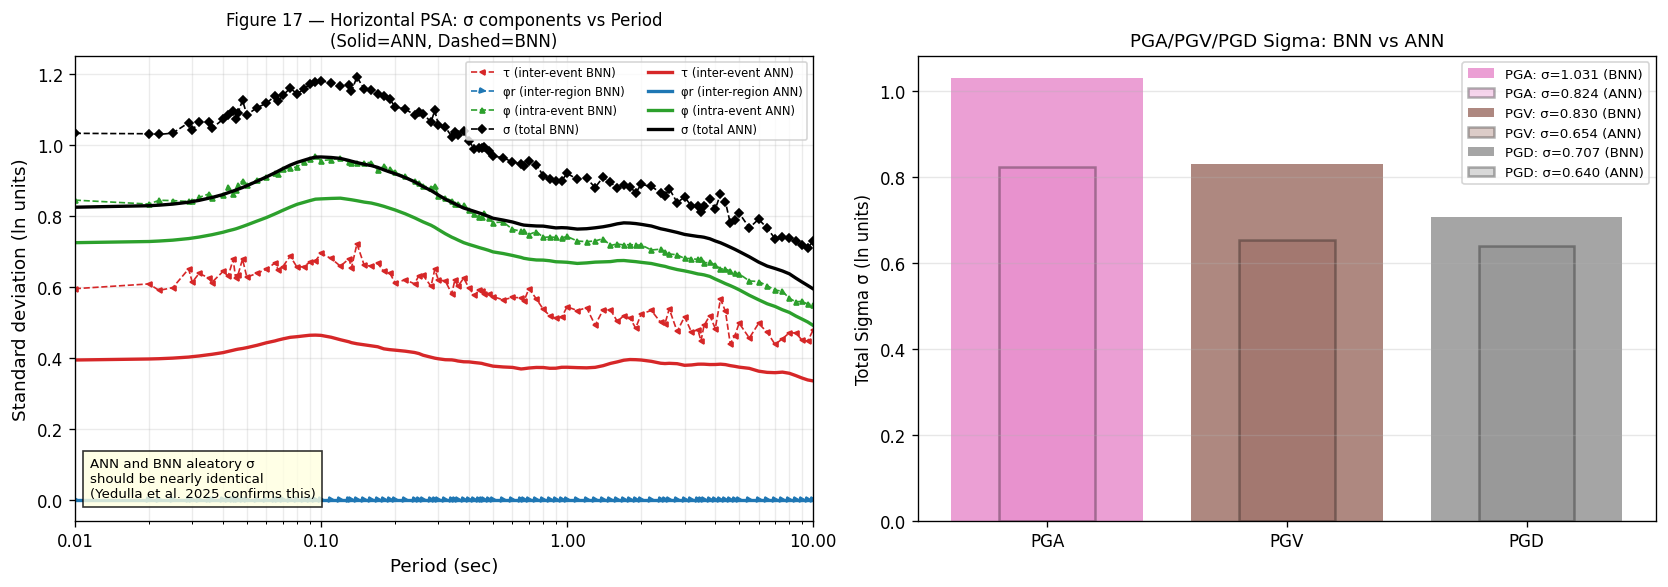

Saved: bnn_fig17_std_deviation.png


In [15]:
T_arr = np.array(PERIOD_VALUES)

tau_bnn  = np.array([me_bnn[i]['tau']   for i in range(105)])
phir_bnn = np.array([me_bnn[i]['phi_r'] for i in range(105)])
phi_bnn  = np.array([me_bnn[i]['phi']   for i in range(105)])
sig_bnn  = np.array([me_bnn[i]['sigma'] for i in range(105)])

tau_ann  = np.array([me_ann[i]['tau']   for i in range(105)])
phir_ann = np.array([me_ann[i]['phi_r'] for i in range(105)])
phi_ann  = np.array([me_ann[i]['phi']   for i in range(105)])
sig_ann  = np.array([me_ann[i]['sigma'] for i in range(105)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_arr, tau_bnn,  marker='<', ms=3, lw=1.0, color='#d62728', ls='--', label='τ (inter-event BNN)')
ax.plot(T_arr, phir_bnn, marker='>', ms=3, lw=1.0, color='#1f77b4', ls='--', label='φr (inter-region BNN)')
ax.plot(T_arr, phi_bnn,  marker='^', ms=3, lw=1.0, color='#2ca02c', ls='--', label='φ (intra-event BNN)')
ax.plot(T_arr, sig_bnn,  marker='D', ms=3, lw=1.0, color='k',       ls='--', label='σ (total BNN)')
ax.plot(T_arr, tau_ann,  lw=2.0, color='#d62728', ls='-', label='τ (inter-event ANN)')
ax.plot(T_arr, phir_ann, lw=2.0, color='#1f77b4', ls='-', label='φr (inter-region ANN)')
ax.plot(T_arr, phi_ann,  lw=2.0, color='#2ca02c', ls='-', label='φ (intra-event ANN)')
ax.plot(T_arr, sig_ann,  lw=2.0, color='k',       ls='-', label='σ (total ANN)')
ax.set_xscale('log')
ax.set_xlabel('Period (sec)', fontsize=11)
ax.set_ylabel('Standard deviation (ln units)', fontsize=11)
ax.set_title('Figure 17 — Horizontal PSA: σ components vs Period\n(Solid=ANN, Dashed=BNN)', fontsize=10)
ax.set_xlim(0.01, 10); ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.text(0.02, 0.05,
    'ANN and BNN aleatory σ\nshould be nearly identical\n(Yedulla et al. 2025 confirms this)',
    transform=ax.transAxes, fontsize=8, bbox=dict(fc='lightyellow', alpha=0.8))

ax = axes[1]
out_names = ['PGA','PGV','PGD']
out_idxs  = [105, 106, 107]
cols_bar  = ['#e377c2','#8c564b','#7f7f7f']
for name, idx, col in zip(out_names, out_idxs, cols_bar):
    ax.bar(name, me_bnn[idx]['sigma'], color=col, alpha=0.7,
           label=f'{name}: σ={me_bnn[idx]["sigma"]:.3f} (BNN)')
    ax.bar(name, me_ann[idx]['sigma'], color=col, alpha=0.3, edgecolor='k', lw=1.5,
           label=f'{name}: σ={me_ann[idx]["sigma"]:.3f} (ANN)', width=0.4)
ax.set_ylabel('Total Sigma σ (ln units)'); ax.set_title('PGA/PGV/PGD Sigma: BNN vs ANN')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bnn_fig17_std_deviation.png')
plt.show()
print("Saved: bnn_fig17_std_deviation.png")


## Cell 16 — Epistemic Uncertainty ⭐ Now Alongside Learned Aleatory Sigma

With the heteroscedastic model we now have **two separate sources of aleatory sigma**:
1. **Residual-based σ_al** (from mixed-effects regression on Δ = y - ŷ) — global average
2. **Learned σ_al** (from the BNN log_sigma head) — scenario-specific

The ensemble spread still gives epistemic σ_ep. Together:

$$\sigma_{total}(T) = \sqrt{\sigma^2_{ep}(T) + \sigma^2_{al}(T)}$$

where σ_al is now the *learned* scenario-specific value rather than a global residual-based constant.


In [16]:
N_ENSEMBLE = 100
print(f"Generating {N_ENSEMBLE} BNN ensemble predictions...")

# Each call returns (n, 216): first 108 = mu, last 108 = log_sigma
ensemble_full_sc = np.stack(
    [model_bnn(X_bnn, training=True).numpy() for _ in range(N_ENSEMBLE)],
    axis=0)  # shape: (100, n, 216)

# Separate mu and log_sigma for each sample
ensemble_mu_sc    = ensemble_full_sc[:, :, :108]    # (100, n, 108) normalized mu
ensemble_logsig_sc = ensemble_full_sc[:, :, 108:]   # (100, n, 108) normalized log_sigma

# Inverse-transform mu to ln space for each sample
ensemble_preds_log = np.stack(
    [scaler_Y_bnn.inverse_transform(ensemble_mu_sc[k]) for k in range(N_ENSEMBLE)],
    axis=0)  # (100, n, 108) — ln space

# Epistemic sigma: spread of mu across 100 runs
sigma2_ep_per_record = ensemble_preds_log.var(axis=0)   # (n, 108)
sigma_ep = np.sqrt(sigma2_ep_per_record.mean(axis=0))   # (108,)

# Learned aleatory sigma: softplus of log_sigma, then convert to ln space
sigma_al_norm_ensemble = np.log1p(np.exp(ensemble_logsig_sc)) + 1e-6  # (100, n, 108)
sigma_al_ln_ensemble   = sigma_al_norm_ensemble / Y_SCALE_FACTOR        # (100, n, 108)
sigma_al_learned       = sigma_al_ln_ensemble.mean(axis=(0, 1))         # (108,) mean over runs & records

print(f"\nEpistemic σ range (PSA 0.01-10s): {sigma_ep[:105].min():.4f} – {sigma_ep[:105].max():.4f} ln")
print(f"Epistemic σ for PGA: {sigma_ep[105]:.4f}")
print()
print(f"Learned aleatory σ range (PSA): {sigma_al_learned[:105].min():.4f} – {sigma_al_learned[:105].max():.4f} ln")
print(f"Residual-based σ (BNN) range  : {sig_bnn.min():.4f} – {sig_bnn.max():.4f} ln")
print()
print(f"Epistemic/Aleatory ratio: ~{(sigma_ep[:105].mean()/sigma_al_learned[:105].mean()*100):.1f}%")


Generating 100 BNN ensemble predictions...

Epistemic σ range (PSA 0.01-10s): 0.2588 – 0.4027 ln
Epistemic σ for PGA: 0.3424

Learned aleatory σ range (PSA): 0.7911 – 1.2621 ln
Residual-based σ (BNN) range  : 0.7101 – 1.1930 ln

Epistemic/Aleatory ratio: ~31.1%


## Cell 17 — Figure 20 Equivalent: Aleatory + Epistemic + Total Uncertainty

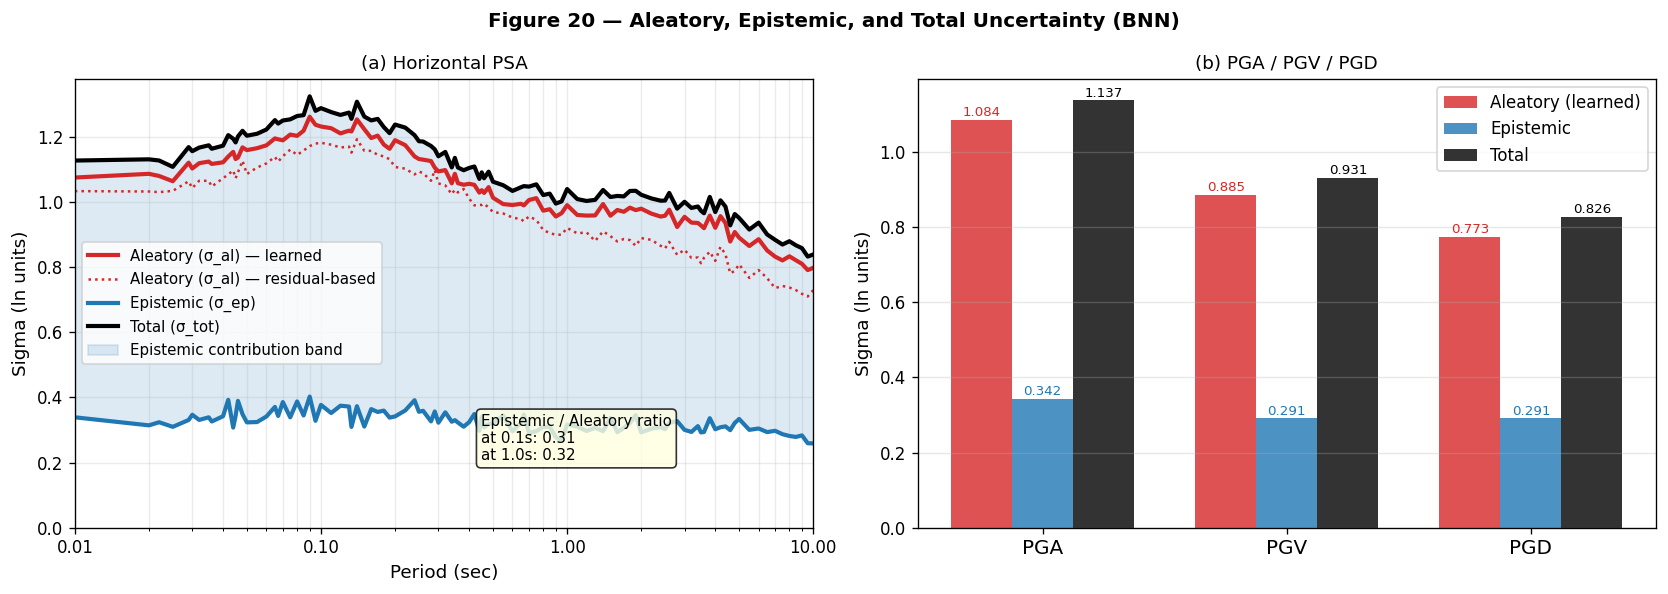

Saved: bnn_fig20_uncertainty.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 20 — Aleatory, Epistemic, and Total Uncertainty (BNN)', fontsize=12, fontweight='bold')

ax = axes[0]
sigma_al_T  = sigma_al_learned[:105]
sigma_ep_T  = sigma_ep[:105]
sigma_tot_T = np.sqrt(sigma_al_T**2 + sigma_ep_T**2)

ax.plot(T_arr, sigma_al_T,  color='#d62728', lw=2.5, label='Aleatory (σ_al) — learned')
ax.plot(T_arr, sig_bnn,     color='#d62728', lw=1.5, ls=':', label='Aleatory (σ_al) — residual-based')
ax.plot(T_arr, sigma_ep_T,  color='#1f77b4', lw=2.5, label='Epistemic (σ_ep)')
ax.plot(T_arr, sigma_tot_T, color='k',       lw=2.5, label='Total (σ_tot)')
ax.fill_between(T_arr, sigma_ep_T, sigma_tot_T, alpha=0.15, color='#1f77b4',
                label='Epistemic contribution band')
ax.set_xscale('log')
ax.set_xlabel('Period (sec)', fontsize=11)
ax.set_ylabel('Sigma (ln units)', fontsize=11)
ax.set_title('(a) Horizontal PSA', fontsize=11)
ax.set_xlim(0.01, 10); ax.set_ylim(0, None)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.25)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.annotate(
    f'Epistemic / Aleatory ratio\n'
    f'at 0.1s: {sigma_ep_T[PERIOD_VALUES.index(0.1)]/sigma_al_T[PERIOD_VALUES.index(0.1)]:.2f}\n'
    f'at 1.0s: {sigma_ep_T[PERIOD_VALUES.index(1.0)]/sigma_al_T[PERIOD_VALUES.index(1.0)]:.2f}',
    xy=(0.55, 0.15), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

ax = axes[1]
labels = ['PGA','PGV','PGD']
idxs   = [105, 106, 107]
x      = np.arange(3); w = 0.25
al_vals  = [sigma_al_learned[i]          for i in idxs]
ep_vals  = [sigma_ep[i]                   for i in idxs]
tot_vals = [np.sqrt(sigma_al_learned[i]**2 + sigma_ep[i]**2) for i in idxs]
ax.bar(x - w, al_vals,  w, label='Aleatory (learned)', color='#d62728', alpha=0.8)
ax.bar(x,     ep_vals,  w, label='Epistemic',           color='#1f77b4', alpha=0.8)
ax.bar(x + w, tot_vals, w, label='Total',               color='k',       alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Sigma (ln units)', fontsize=11)
ax.set_title('(b) PGA / PGV / PGD', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for xi, (a,e,t) in zip(x, zip(al_vals, ep_vals, tot_vals)):
    ax.text(xi-w, a+0.01, f'{a:.3f}', ha='center', fontsize=8, color='#d62728')
    ax.text(xi,   e+0.01, f'{e:.3f}', ha='center', fontsize=8, color='#1f77b4')
    ax.text(xi+w, t+0.01, f'{t:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('bnn_fig20_uncertainty.png')
plt.show()
print("Saved: bnn_fig20_uncertainty.png")


## Cell 18 — Figure 18/19 Equivalent: 100 BNN Ensemble Predictions

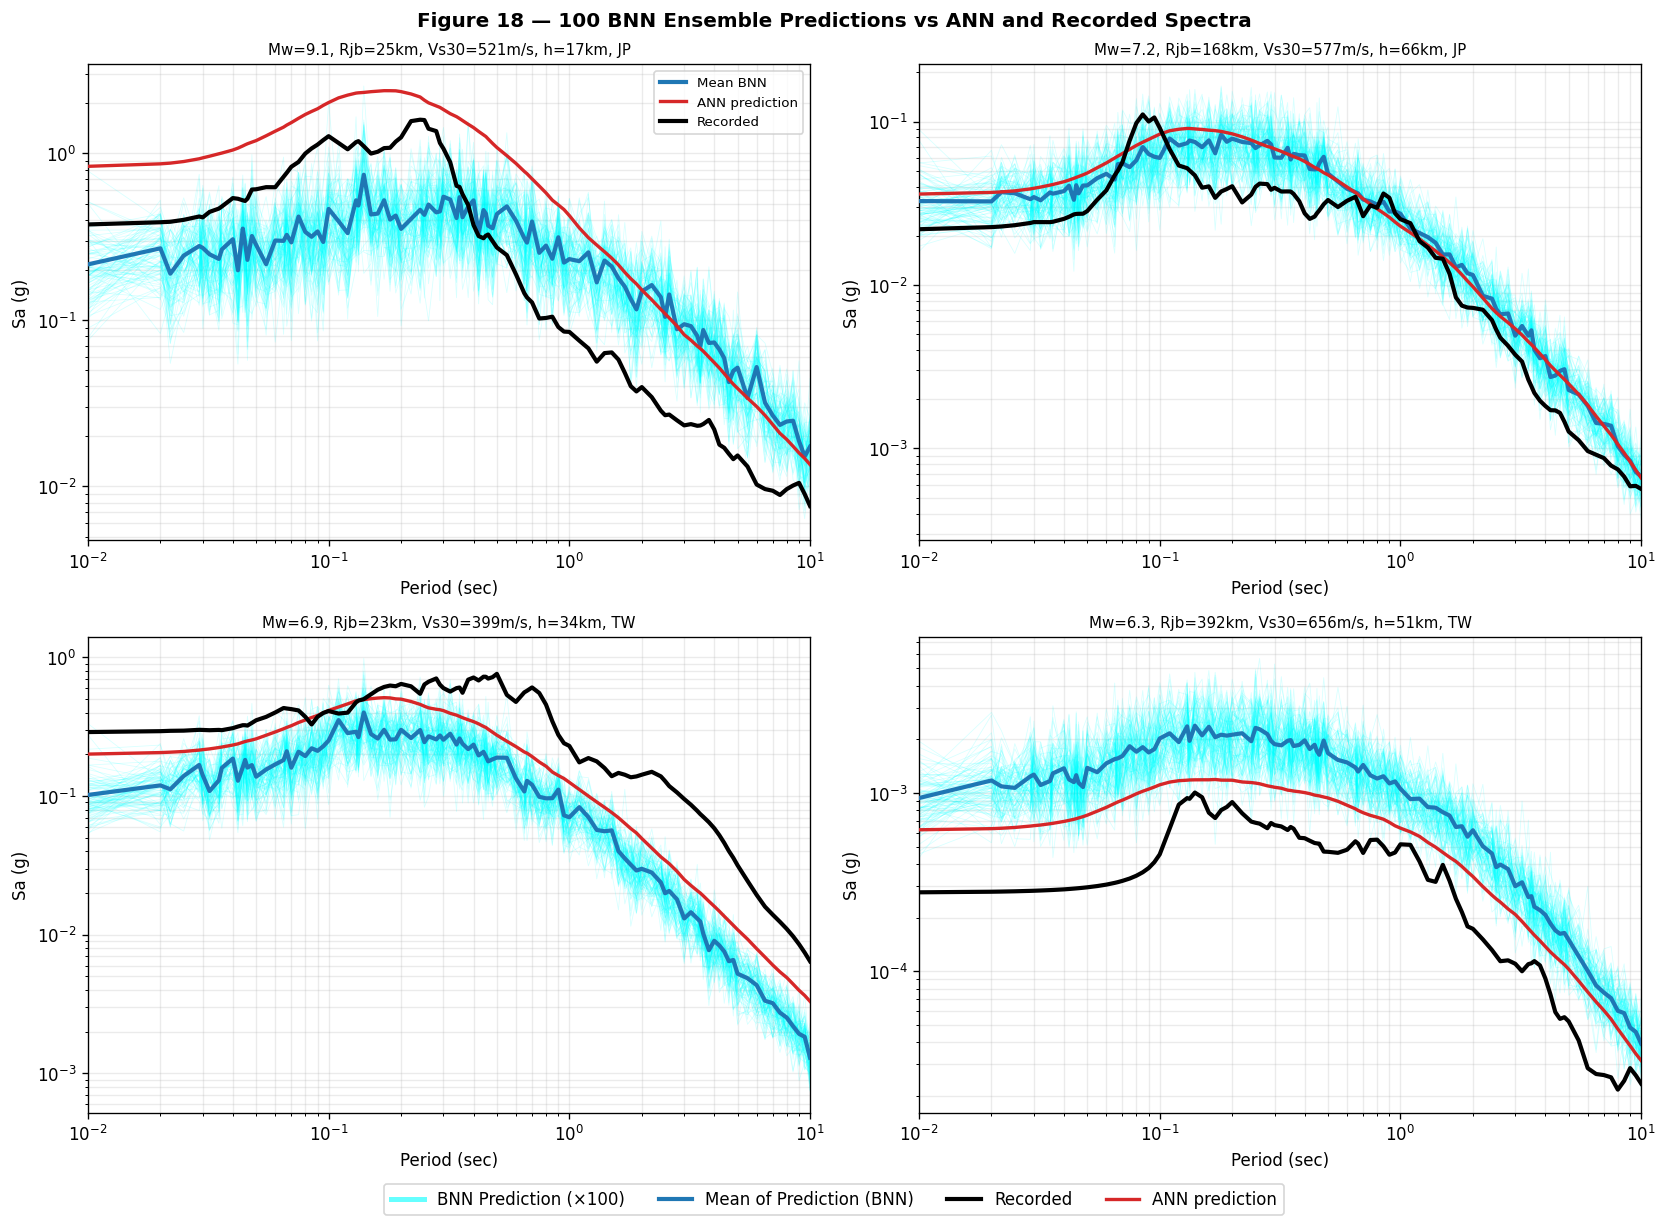

Saved: bnn_fig18_ensemble.png


In [18]:
Mw_te   = MW_ALL[idx_test]
Rjb_te  = RJB_ALL[idx_test]
Reg_te  = REGION_IDS[idx_test]

def find_record(mw_min, mw_max, rjb_min, rjb_max):
    mask = ((Mw_te >= mw_min) & (Mw_te < mw_max) &
            (Rjb_te >= rjb_min) & (Rjb_te < rjb_max))
    if mask.any():
        return idx_test[np.where(mask)[0][0]]
    return idx_test[0]

sample_recs = [
    find_record(7.5, 9.5,  0,  50),
    find_record(7.0, 8.0, 50, 200),
    find_record(5.5, 7.0,  0,  80),
    find_record(5.0, 6.5, 200, 600),
]

T_plot = np.array(PERIOD_VALUES)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 18 — 100 BNN Ensemble Predictions vs ANN and Recorded Spectra', fontsize=12, fontweight='bold')

for ax, rec_idx in zip(axes.flatten(), sample_recs):
    ens_log  = ensemble_preds_log[:, rec_idx, :105]
    ens_g    = np.exp(ens_log)
    ens_mean_g = ens_g.mean(axis=0)

    ann_log = Y_ann_pred_log[rec_idx, :105]
    ann_g   = np.exp(ann_log)
    rec_log = Y_true_log[rec_idx, :105]
    rec_g   = np.exp(rec_log)

    for k in range(100):
        ax.loglog(T_plot, ens_g[k], color='cyan', alpha=0.15, lw=0.5)
    ax.loglog(T_plot, ens_mean_g, color='#1f77b4', lw=2.5, label='Mean BNN', zorder=5)
    ax.loglog(T_plot, ann_g,      color='#d62728', lw=2.0, ls='-', label='ANN prediction', zorder=6)
    ax.loglog(T_plot, rec_g,      color='k',       lw=2.5, label='Recorded', zorder=7)

    mw_r   = MW_ALL[rec_idx]; rjb_r  = RJB_ALL[rec_idx]
    vs30_r = VS30_ALL[rec_idx]; dep_r = DEPTH_ALL[rec_idx]
    reg_r  = REGION_NAMES.get(REGION_IDS[rec_idx], '?')
    ax.set_title(f'Mw={mw_r:.1f}, Rjb={rjb_r:.0f}km, Vs30={vs30_r:.0f}m/s, h={dep_r:.0f}km, {reg_r}',
                 fontsize=9)
    ax.set_xlabel('Period (sec)'); ax.set_ylabel('Sa (g)')
    ax.set_xlim(0.01, 10); ax.grid(True, which='both', alpha=0.25)
    if ax == axes[0][0]:
        ax.legend(fontsize=8, loc='upper right')

legend_els = [
    plt.Line2D([0],[0], color='cyan', alpha=0.6, lw=3, label='BNN Prediction (×100)'),
    plt.Line2D([0],[0], color='#1f77b4', lw=2.5, label='Mean of Prediction (BNN)'),
    plt.Line2D([0],[0], color='k', lw=2.5, label='Recorded'),
    plt.Line2D([0],[0], color='#d62728', lw=2.0, label='ANN prediction'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('bnn_fig18_ensemble.png', bbox_inches='tight')
plt.show()
print("Saved: bnn_fig18_ensemble.png")


## Cell 19 — Figure 14 Equivalent: Residual Analysis for BNN

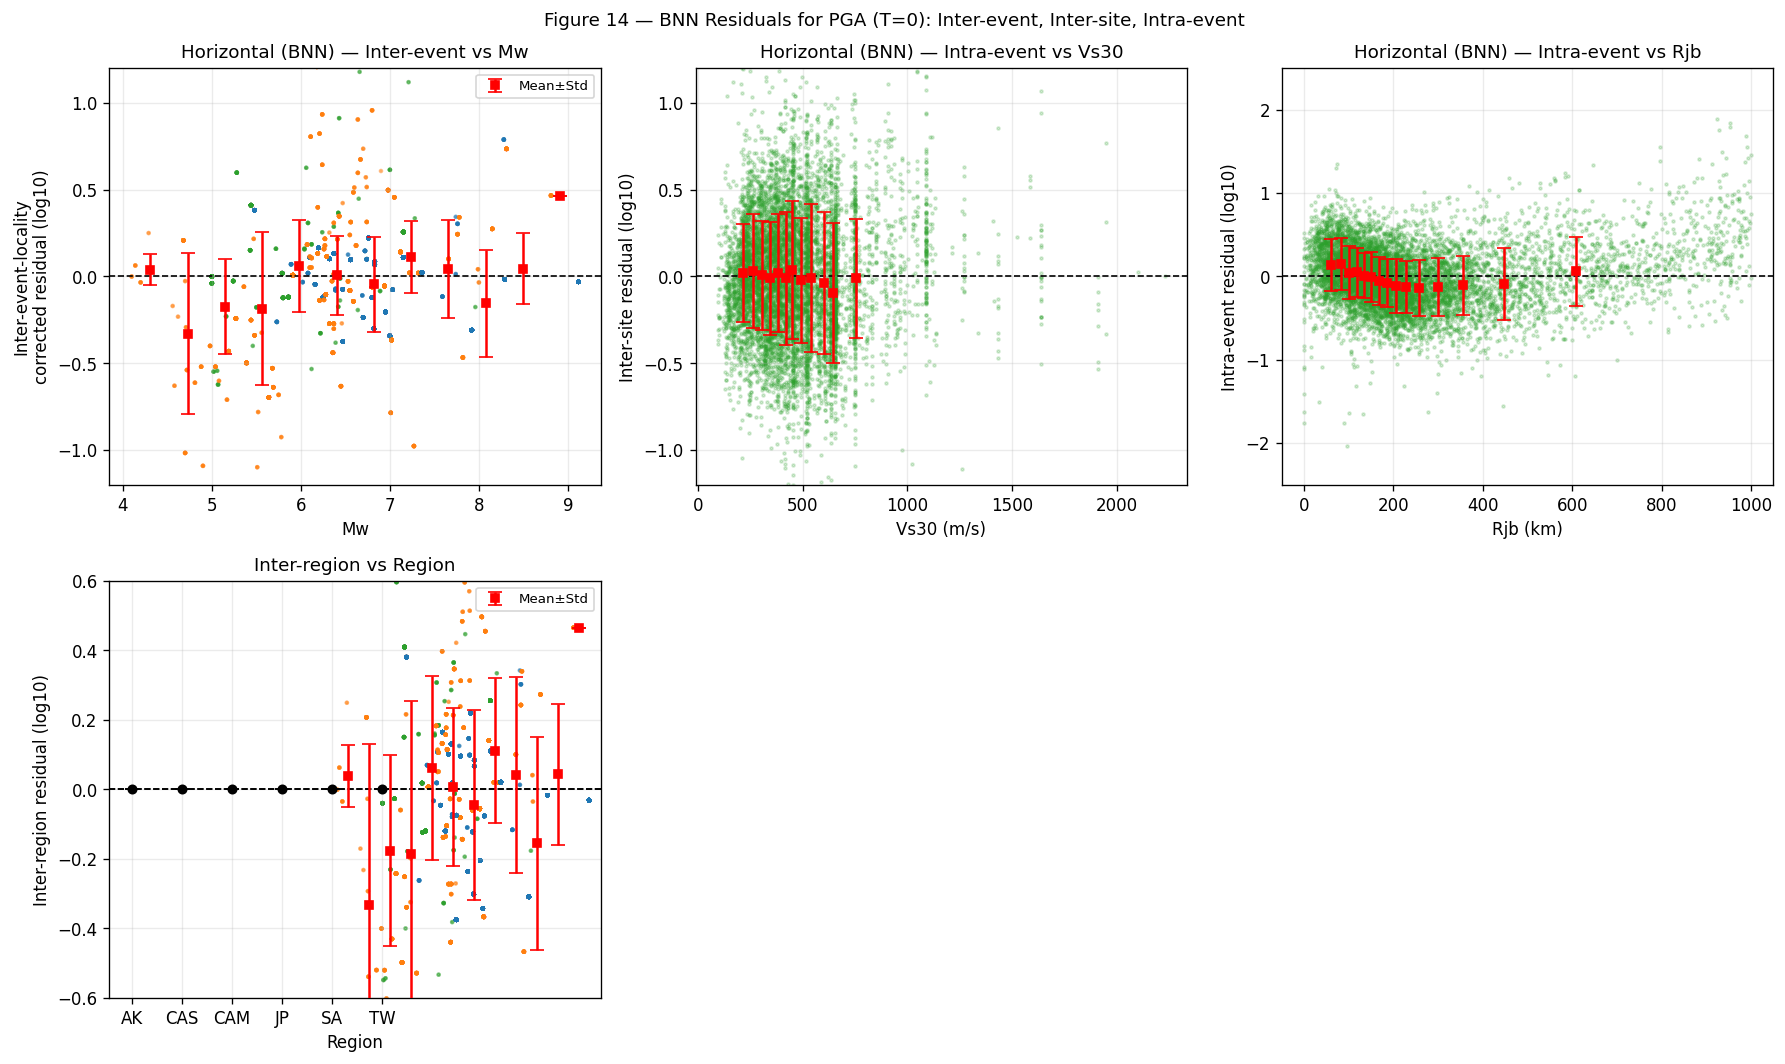

Saved: bnn_fig14_residuals.png


In [19]:
T0_idx = get_out_idx(0)

def bin_stats(x, y, n_bins=12, pctile=True):
    edges = np.percentile(x, np.linspace(5, 95, n_bins+1)) if pctile else np.linspace(x.min(), x.max(), n_bins+1)
    cx, cm, cs = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if m.sum() >= 3:
            cx.append((lo+hi)/2); cm.append(y[m].mean()); cs.append(y[m].std())
    return np.array(cx), np.array(cm), np.array(cs)

Be_bnn  = me_bnn[T0_idx]['Be']
Wes_bnn = me_bnn[T0_idx]['Wes']
Rr_bnn  = me_bnn[T0_idx]['Rr']
Be_l10  = Be_bnn  / np.log(10)
Wes_l10 = Wes_bnn / np.log(10)
Rr_l10  = Rr_bnn  / np.log(10)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 14 — BNN Residuals for PGA (T=0): Inter-event, Inter-site, Intra-event', fontsize=11)

for row, (label, resid_l10, is_top) in enumerate(zip(
        ['Horizontal (BNN)', 'V/H ratio (N/A — NGA-Sub)'],
        [Be_l10, Wes_l10], [True, False])):

    ax = axes[row][0]
    ax.scatter(MW_ALL, Be_l10, s=3, alpha=0.25,
               color=['#1f77b4' if r==4 else '#2ca02c' if r==1 else '#ff7f0e'
                       for r in REGION_IDS], rasterized=True)
    cx, cm, cs = bin_stats(MW_ALL, Be_l10, n_bins=12, pctile=False)
    ax.errorbar(cx, cm, yerr=cs, fmt='rs', ms=5, capsize=4, lw=1.5, zorder=5, label='Mean±Std')
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mw'); ax.set_ylabel('Inter-event-locality\ncorrected residual (log10)')
    ax.set_title(f'{label} — Inter-event vs Mw')
    ax.set_ylim(-1.2, 1.2); ax.grid(alpha=0.25); ax.legend(fontsize=8)

    ax = axes[row][1]
    ax.scatter(VS30_ALL, Wes_l10, s=3, alpha=0.2, color='#2ca02c', rasterized=True)
    cx2, cm2, cs2 = bin_stats(VS30_ALL, Wes_l10, n_bins=12)
    ax.errorbar(cx2, cm2, yerr=cs2, fmt='rs', ms=5, capsize=4, lw=1.5, zorder=5)
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Vs30 (m/s)'); ax.set_ylabel('Inter-site residual (log10)')
    ax.set_title(f'{label} — Intra-event vs Vs30')
    ax.set_ylim(-1.2, 1.2); ax.grid(alpha=0.25)

    ax = axes[row][2]
    ax.scatter(RJB_ALL, Wes_l10, s=3, alpha=0.2, color='#2ca02c', rasterized=True)
    cx3, cm3, cs3 = bin_stats(RJB_ALL, Wes_l10, n_bins=15)
    ax.errorbar(cx3, cm3, yerr=cs3, fmt='rs', ms=5, capsize=4, lw=1.5, zorder=5)
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Rjb (km)'); ax.set_ylabel('Intra-event residual (log10)')
    ax.set_title(f'{label} — Intra-event vs Rjb')
    ax.set_ylim(-2.5, 2.5); ax.grid(alpha=0.25)

axes[1][0].set_ylabel('Inter-region residual (log10)')
for rg_id, rg_name in REGION_NAMES.items():
    m = REGION_IDS == rg_id
    if m.any():
        axes[1][0].scatter([rg_name]*m.sum(), Rr_l10[m], s=4, alpha=0.25,
                            color=REGION_COLORS[rg_id], rasterized=True)
        axes[1][0].errorbar(rg_name, Rr_l10[m].mean(), yerr=Rr_l10[m].std(),
                             fmt='o', color='k', ms=5, capsize=4, lw=1.5, zorder=5)
axes[1][0].axhline(0, color='k', lw=1, ls='--')
axes[1][0].set_xlabel('Region'); axes[1][0].set_title('Inter-region vs Region')
axes[1][0].set_ylim(-0.6, 0.6); axes[1][0].grid(alpha=0.25)
axes[1][1].set_visible(False); axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('bnn_fig14_residuals.png')
plt.show()
print("Saved: bnn_fig14_residuals.png")


## Cell 20 — ⭐ NEW: Calibration Check

A well-trained probabilistic model must be **calibrated**: if the model says "90% prediction interval", then 90% of observations should actually fall inside it.

### What we check

**Reliability diagram (left):** For each nominal coverage level α (x-axis), we compute the actual fraction of test records whose true log-Sa falls within the α-prediction interval (y-axis).  
- **Perfect calibration** = diagonal line  
- **Above diagonal** = overconfident (intervals too narrow — underestimates uncertainty)  
- **Below diagonal** = underconfident (intervals too wide)

Mean-field VI is known to be slightly overconfident. We check whether the heteroscedastic + KL annealing improvements correct this.

**PICP vs Period (right):** The 90% prediction interval coverage probability (PICP) computed at each period. Should be flat at 0.90 across all periods for a calibrated model.

### What goes into the prediction interval

The total predictive interval accounts for **both** epistemic and aleatory uncertainty:
- Epistemic: from the spread across ensemble mu values
- Aleatory: from the learned sigma head

We sample the **total predictive distribution** as:

$$\tilde{y}_k = \mu_k + \sigma_{al,k} \cdot \varepsilon_k, \quad \varepsilon_k \sim \mathcal{N}(0, I)$$

and compute coverage of these joint samples.


Running calibration check on test set...
Test records: 2673 | Ensemble size: 100


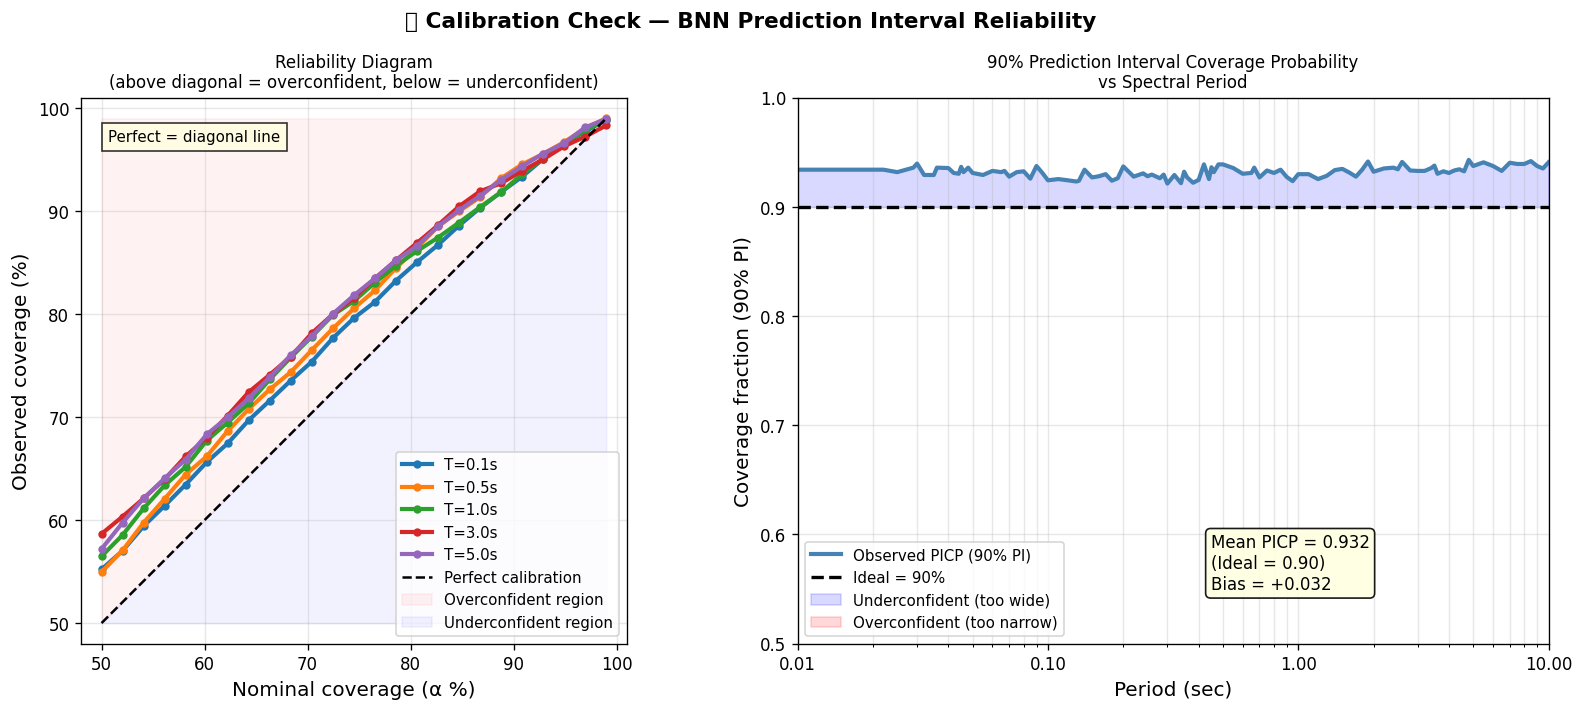

Saved: bnn_fig_calibration.png

Mean PICP at 90% nominal: 0.932
✓  PICP in [0.85, 0.95] → Model is reasonably well-calibrated.

Computing optimal temperature for post-hoc calibration...
Optimal temperature T* = 0.857
  T* < 1.0 → model is underconfident; multiply σ by 0.857 to recalibrate.


In [20]:
print("Running calibration check on test set...")
print(f"Test records: {len(idx_test)} | Ensemble size: {N_ENSEMBLE}")

# ── Build total predictive samples (epistemic + aleatory) on test set
# For each of the 100 ensemble runs:
#   mu_k      in ln space   (from mu head, inverse-transformed)
#   sigma_al_k in ln space  (from log_sigma head, converted to ln)
ensemble_mu_test_ln    = ensemble_preds_log[:, idx_test, :]              # (100, n_te, 108)
sigma_al_norm_test     = np.log1p(np.exp(ensemble_logsig_sc[:, idx_test, :])) + 1e-6
sigma_al_test_ln       = sigma_al_norm_test / Y_SCALE_FACTOR              # (100, n_te, 108)

np.random.seed(0)
# Sample from total predictive: y_k = mu_k + sigma_al_k * eps_k
eps = np.random.randn(*ensemble_mu_test_ln.shape)
total_predictive_samples_ln = ensemble_mu_test_ln + sigma_al_test_ln * eps
# shape: (100, n_te, 108) — these represent the full predictive uncertainty

# True values on test set (in ln space)
Y_te_true_ln = Y_true_log[idx_test, :]   # (n_te, 108)

# ── Reliability diagram (Figure A — left panel)
alpha_levels = np.linspace(0.50, 0.99, 25)
sel_periods_calib = [0.1, 0.5, 1.0, 3.0, 5.0]
sel_period_labels = ['T=0.1s', 'T=0.5s', 'T=1.0s', 'T=3.0s', 'T=5.0s']
sel_colors        = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('⭐ Calibration Check — BNN Prediction Interval Reliability', fontsize=13, fontweight='bold')

ax = axes[0]
for sp, slabel, scol in zip(sel_periods_calib, sel_period_labels, sel_colors):
    pi = get_out_idx(sp)
    y_true = Y_te_true_ln[:, pi]           # (n_te,)
    samples = total_predictive_samples_ln[:, :, pi]  # (100, n_te)

    coverages = []
    for alpha in alpha_levels:
        lower = np.percentile(samples, (1 - alpha) / 2 * 100, axis=0)
        upper = np.percentile(samples, (1 + alpha) / 2 * 100, axis=0)
        covered = np.mean((y_true >= lower) & (y_true <= upper))
        coverages.append(covered)

    ax.plot(alpha_levels * 100, np.array(coverages) * 100,
            lw=2.5, color=scol, marker='o', ms=4, label=slabel)

ax.plot([50, 99], [50, 99], 'k--', lw=1.5, label='Perfect calibration', zorder=10)
ax.fill_between([50, 99], [50, 99], [99, 99], alpha=0.05, color='red', label='Overconfident region')
ax.fill_between([50, 99], [50, 50], [50, 99], alpha=0.05, color='blue', label='Underconfident region')
ax.set_xlabel('Nominal coverage (α %)', fontsize=12)
ax.set_ylabel('Observed coverage (%)', fontsize=12)
ax.set_title('Reliability Diagram\n(above diagonal = overconfident, below = underconfident)', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(48, 101); ax.set_ylim(48, 101)
ax.set_aspect('equal')
ax.text(0.05, 0.92, 'Perfect = diagonal line', transform=ax.transAxes, fontsize=9,
        bbox=dict(fc='lightyellow', alpha=0.8))

# ── PICP at 90% vs Period (right panel)
ax = axes[1]
picp_90_per_period = []
for i in range(105):
    y_true  = Y_te_true_ln[:, i]
    samples = total_predictive_samples_ln[:, :, i]
    lower   = np.percentile(samples,  5, axis=0)
    upper   = np.percentile(samples, 95, axis=0)
    picp_90_per_period.append(float(np.mean((y_true >= lower) & (y_true <= upper))))

ax.semilogx(PERIOD_VALUES, picp_90_per_period, lw=2.5, color='steelblue',
            label='Observed PICP (90% PI)')
ax.axhline(0.90, color='k', ls='--', lw=2, label='Ideal = 90%')
ax.fill_between(PERIOD_VALUES,
                [0.90]*len(PERIOD_VALUES), picp_90_per_period,
                where=[p > 0.90 for p in picp_90_per_period],
                alpha=0.15, color='blue', label='Underconfident (too wide)')
ax.fill_between(PERIOD_VALUES,
                picp_90_per_period, [0.90]*len(PERIOD_VALUES),
                where=[p < 0.90 for p in picp_90_per_period],
                alpha=0.15, color='red', label='Overconfident (too narrow)')
ax.set_xlabel('Period (sec)', fontsize=12)
ax.set_ylabel('Coverage fraction (90% PI)', fontsize=12)
ax.set_title('90% Prediction Interval Coverage Probability\nvs Spectral Period', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
ax.set_ylim(0.5, 1.0); ax.set_xlim(0.01, 10)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

mean_picp = np.mean(picp_90_per_period)
ax.text(0.55, 0.10,
        f'Mean PICP = {mean_picp:.3f}\n'
        f'(Ideal = 0.90)\n'
        f'Bias = {mean_picp - 0.90:+.3f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('bnn_fig_calibration.png')
plt.show()
print("Saved: bnn_fig_calibration.png")
print()
print(f"Mean PICP at 90% nominal: {mean_picp:.3f}")
if mean_picp < 0.85:
    print("⚠  PICP < 0.85 → Model is OVERCONFIDENT. Consider temperature scaling.")
elif mean_picp > 0.95:
    print("⚠  PICP > 0.95 → Model is UNDERCONFIDENT. Intervals are too wide.")
else:
    print("✓  PICP in [0.85, 0.95] → Model is reasonably well-calibrated.")
print()

# ── Optional: temperature scaling if overconfident
# Temperature T > 1 widens intervals; T < 1 narrows them.
# Optimal T found by minimizing NLL on held-out set:
print("Computing optimal temperature for post-hoc calibration...")
from scipy.optimize import minimize_scalar

def neg_log_lik_T(log_T):
    T = np.exp(log_T)
    mu_te    = ensemble_mu_test_ln.mean(axis=0)      # (n_te, 108)
    sigma_te = sigma_al_test_ln.mean(axis=0) * T     # scaled by temperature
    sigma_ep_te = ensemble_mu_test_ln.std(axis=0)    # epistemic contribution
    sigma_tot_te = np.sqrt(sigma_te**2 + sigma_ep_te**2 * T**2)
    nll = np.mean(0.5 * (Y_te_true_ln - mu_te)**2 / sigma_tot_te**2
                  + np.log(sigma_tot_te))
    return float(nll)

result = minimize_scalar(neg_log_lik_T, bounds=(-1, 2), method='bounded')
T_optimal = np.exp(result.x)
print(f"Optimal temperature T* = {T_optimal:.3f}")
if abs(T_optimal - 1.0) < 0.05:
    print("  T* ≈ 1.0 → uncertainties are well-calibrated without scaling.")
elif T_optimal > 1.0:
    print(f"  T* > 1.0 → model is overconfident; multiply σ by {T_optimal:.3f} to recalibrate.")
else:
    print(f"  T* < 1.0 → model is underconfident; multiply σ by {T_optimal:.3f} to recalibrate.")


## Cell 21 — Figure 5 Equivalent: Sa vs Magnitude (Physics Check)

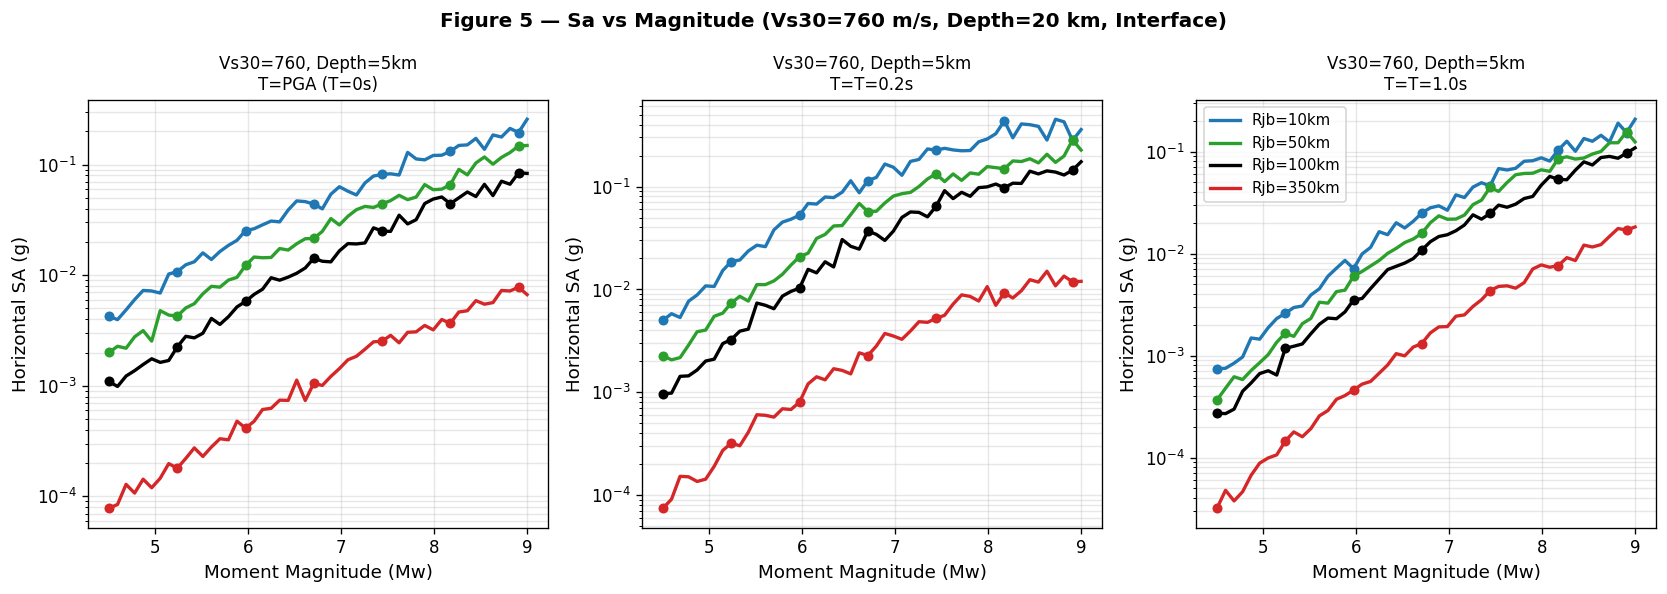

Saved: bnn_fig5_sa_vs_mw.png


In [21]:
def bnn_predict_mean(Mw, Rjb_km, Depth_km, Vs30_ms, region_flag, n_samples=20):
    """
    Predict mean + std using BNN ensemble.
    Returns: psa_mean (n,105), psa_std (n,105), pga_mean (n,), pga_std (n,)
    """
    FM = {0:1,1:2,5:3}.get(int(region_flag), 4)
    R = np.atleast_1d(Rjb_km)
    n = len(R)
    X_in = np.column_stack([
        np.full(n, Mw), R,
        np.log(np.maximum(R, 0.01)),
        np.full(n, np.log(Vs30_ms)),
        np.full(n, Depth_km),
        np.full(n, FM),
    ]).astype(np.float32)
    X_sc = scaler_X_bnn.transform(X_in)
    preds_full = np.stack([model_bnn(X_sc, training=True).numpy() for _ in range(n_samples)], axis=0)
    mu_sc = preds_full[:, :, :108]
    logsig_sc = preds_full[:, :, 108:]
    preds_log = np.stack([scaler_Y_bnn.inverse_transform(mu_sc[k]) for k in range(n_samples)], axis=0)
    # epistemic std from mu spread; aleatory from sigma head
    mu_log_mean  = preds_log.mean(axis=0)           # (n, 108)
    ep_std_log   = preds_log.std(axis=0)             # (n, 108)
    al_norm_mean = (np.log1p(np.exp(logsig_sc)) + 1e-6).mean(axis=0)  # (n, 108)
    al_ln_mean   = al_norm_mean / Y_SCALE_FACTOR                       # (n, 108)
    tot_std_log  = np.sqrt(ep_std_log**2 + al_ln_mean**2)
    preds_g  = np.exp(mu_log_mean)
    preds_sg = np.exp(tot_std_log)
    return (preds_g[:, :105], preds_sg[:, :105],
            preds_g[:, 105],  preds_sg[:, 105])

Mw_range = np.linspace(4.5, 9.0, 50)
sample_periods = [0.0, 0.2, 1.0]
R_samples = [10, 50, 100, 350]
R_colors  = ['#1f77b4','#2ca02c','k','#d62728']
R_labels  = ['Rjb=10km','Rjb=50km','Rjb=100km','Rjb=350km']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 5 — Sa vs Magnitude (Vs30=760 m/s, Depth=20 km, Interface)',
             fontsize=12, fontweight='bold')

for ax, sp in zip(axes, sample_periods):
    for Rjb_fix, col, lbl in zip(R_samples, R_colors, R_labels):
        sa_vals = []
        for mw in Mw_range:
            psa_m, psa_s, pga_m, pga_s = bnn_predict_mean(mw, Rjb_fix, 20, 760, 0, n_samples=10)
            if sp == 0.0:
                sa_vals.append(pga_m[0])
            else:
                pi = get_out_idx(sp)
                sa_vals.append(psa_m[0, pi])
        sa_vals = np.array(sa_vals)
        ax.semilogy(Mw_range, sa_vals, color=col, lw=2.0, label=lbl)
        ax.plot(Mw_range[::8], sa_vals[::8], 'o', color=col, ms=5)

    ax.set_xlabel('Moment Magnitude (Mw)', fontsize=11)
    ax.set_ylabel('Horizontal SA (g)', fontsize=11)
    t_label = 'PGA (T=0s)' if sp==0 else f'T={sp}s'
    ax.set_title(f'Vs30=760, Depth=5km\nT={t_label}', fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    if ax == axes[2]: ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('bnn_fig5_sa_vs_mw.png')
plt.show()
print("Saved: bnn_fig5_sa_vs_mw.png")


## Cell 22 — Figure 6 Equivalent: Sa vs Distance with Epistemic Uncertainty Bands

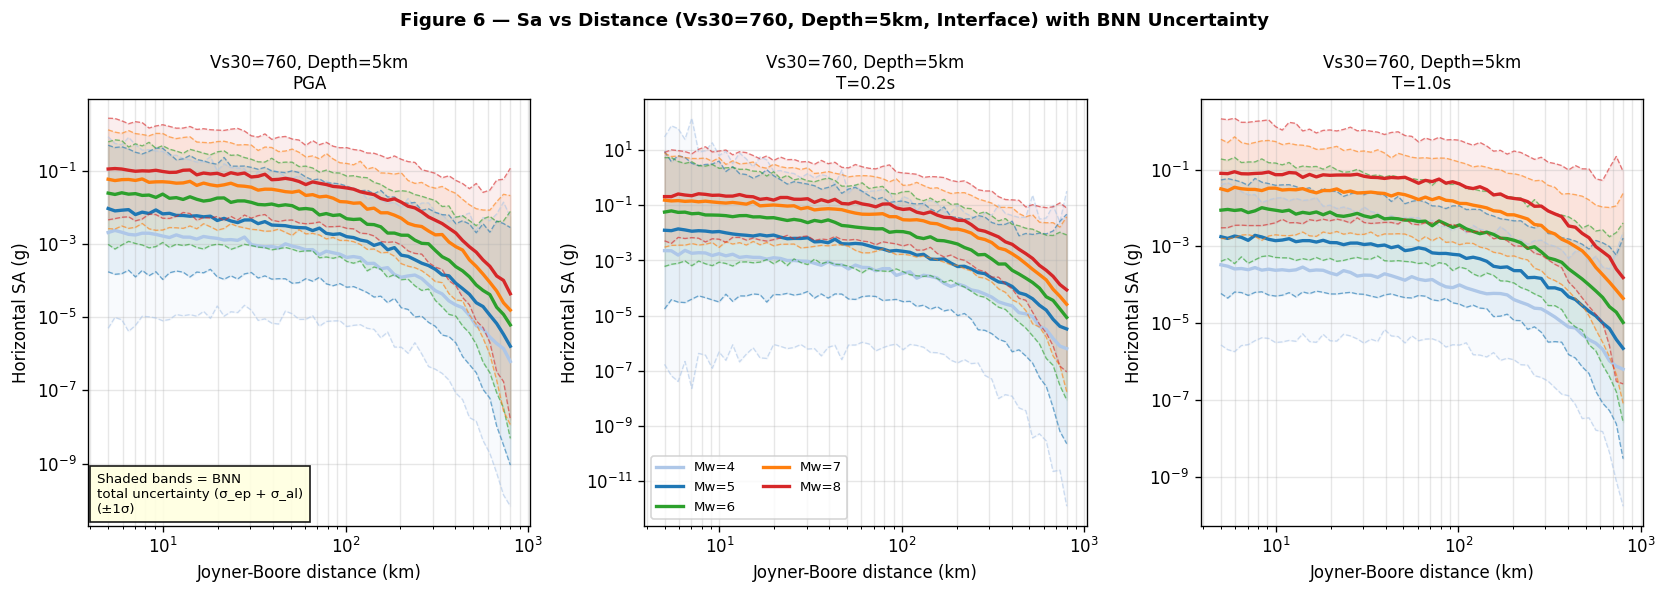

Saved: bnn_fig6_sa_vs_rjb.png


In [22]:
R_range = np.logspace(np.log10(5), np.log10(800), 60)
Mw_list = [4, 5, 6, 7, 8]
Mw_colors = ['#aec7e8','#1f77b4','#2ca02c','#ff7f0e','#d62728']
T_panels = [0.0, 0.2, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 6 — Sa vs Distance (Vs30=760, Depth=5km, Interface) with BNN Uncertainty',
             fontsize=11, fontweight='bold')

for ax, sp in zip(axes, T_panels):
    t_label = 'PGA' if sp==0 else f'T={sp}s'
    for mw, col in zip(Mw_list, Mw_colors):
        sa_mean, sa_std = [], []
        for R in R_range:
            psa_m, psa_s, pga_m, pga_s = bnn_predict_mean(mw, R, 5, 760, 0, n_samples=15)
            if sp == 0.0:
                sa_mean.append(pga_m[0]); sa_std.append(pga_s[0])
            else:
                pi = get_out_idx(sp)
                sa_mean.append(psa_m[0, pi]); sa_std.append(psa_s[0, pi])
        sa_m = np.array(sa_mean); sa_s = np.array(sa_std)
        ax.loglog(R_range, sa_m, color=col, lw=2.0, ls='-', label=f'Mw={mw}')
        ax.loglog(R_range, sa_m*np.exp(-sa_s), color=col, lw=0.8, ls='--', alpha=0.6)
        ax.loglog(R_range, sa_m*np.exp( sa_s), color=col, lw=0.8, ls='--', alpha=0.6)
        ax.fill_between(R_range, sa_m*np.exp(-sa_s), sa_m*np.exp(sa_s),
                        color=col, alpha=0.08)
    ax.set_xlabel('Joyner-Boore distance (km)', fontsize=10)
    ax.set_ylabel('Horizontal SA (g)', fontsize=10)
    ax.set_title(f'Vs30=760, Depth=5km\n{t_label}', fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    if ax == axes[1]: ax.legend(fontsize=8, ncol=2, loc='lower left')

axes[0].annotate('Shaded bands = BNN\ntotal uncertainty (σ_ep + σ_al)\n(±1σ)',
                xy=(0.02, 0.03), xycoords='axes fraction', fontsize=8,
                bbox=dict(fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('bnn_fig6_sa_vs_rjb.png')
plt.show()
print("Saved: bnn_fig6_sa_vs_rjb.png")


## Cell 23 — Figure 7 Equivalent: Response Spectra vs Period with Depth Variation

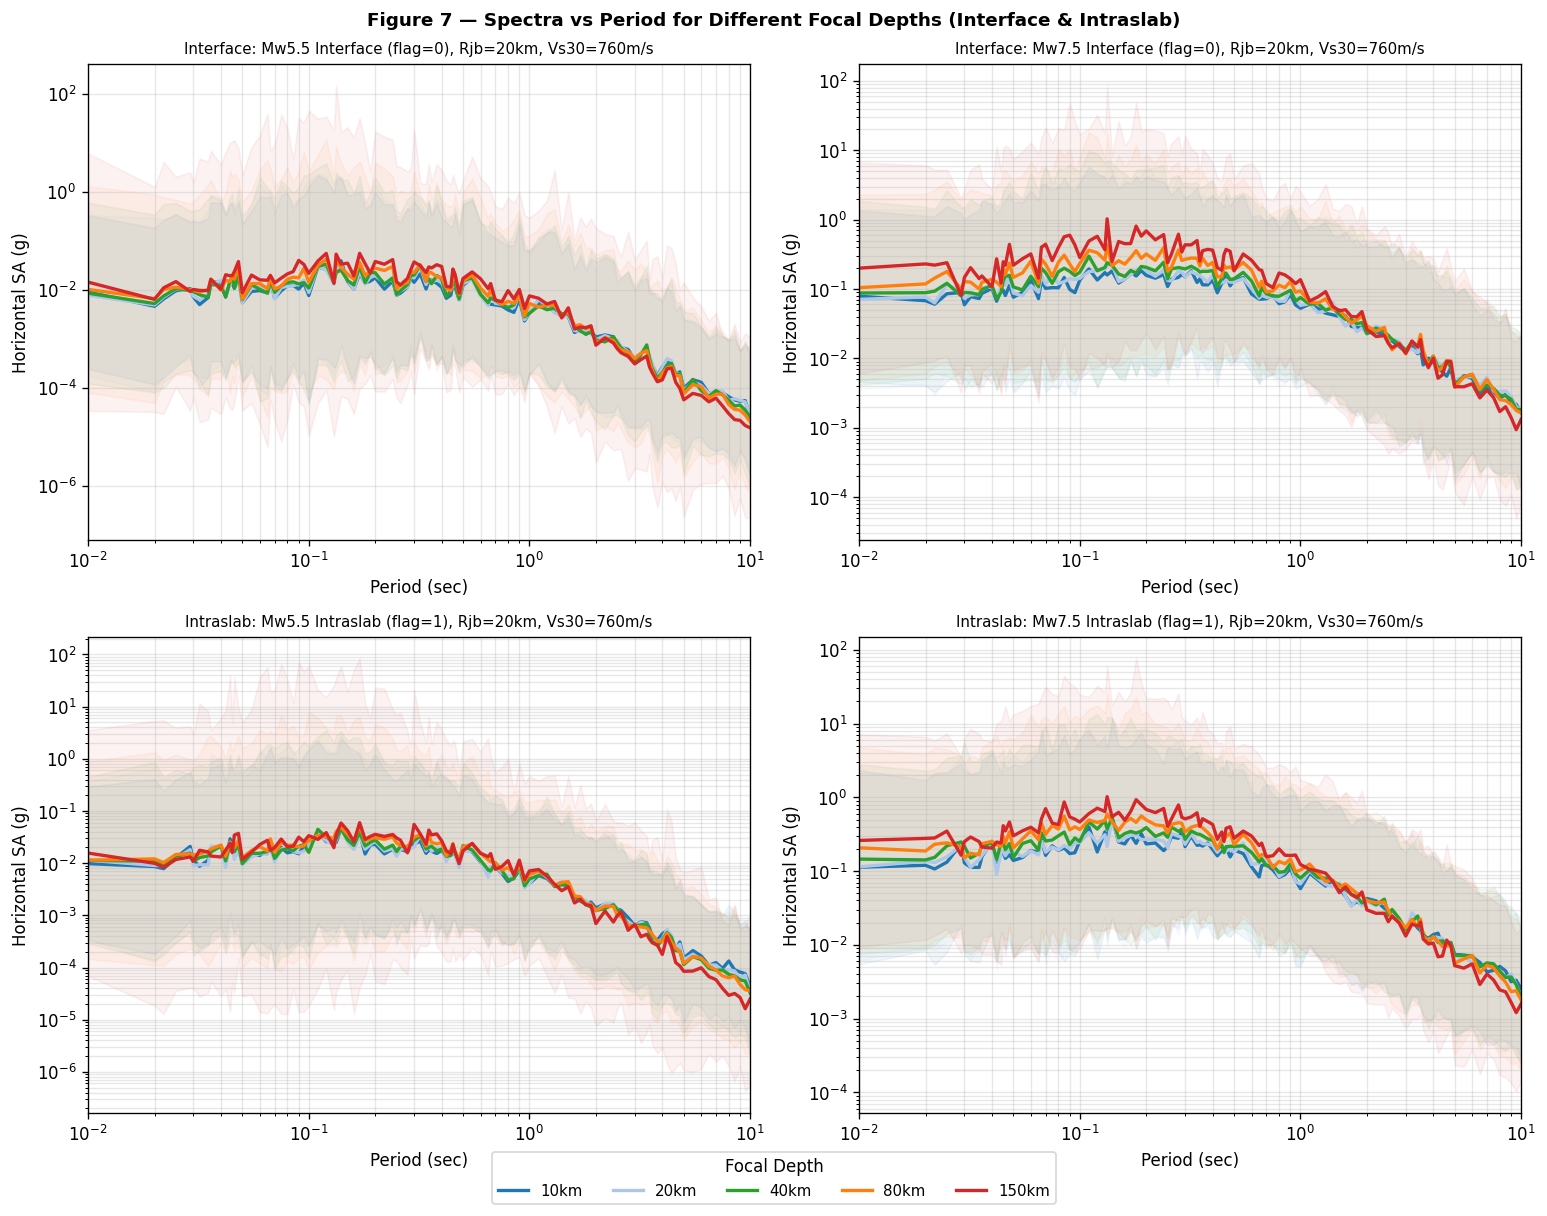

Saved: bnn_fig7_spectra_depth.png


In [23]:
T_arr_plot = np.array(PERIOD_VALUES)
depths = [10, 20, 40, 80, 150]
depth_colors = ['#1f77b4','#aec7e8','#2ca02c','#ff7f0e','#d62728']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Figure 7 — Spectra vs Period for Different Focal Depths (Interface & Intraslab)',
             fontsize=11, fontweight='bold')

scenarios = [
    (5.5, 20, 760, 0, 'Interface', 'Mw5.5 Interface (flag=0)'),
    (7.5, 20, 760, 0, 'Interface', 'Mw7.5 Interface (flag=0)'),
    (5.5, 20, 760, 1, 'Intraslab', 'Mw5.5 Intraslab (flag=1)'),
    (7.5, 20, 760, 1, 'Intraslab', 'Mw7.5 Intraslab (flag=1)'),
]

for ax, (mw, rjb, vs30, flag, ftype, title) in zip(axes.flatten(), scenarios):
    for d, col in zip(depths, depth_colors):
        psa_m, psa_s, pga_m, _ = bnn_predict_mean(mw, rjb, d, vs30, flag, n_samples=10)
        sa_full = np.concatenate([[pga_m[0]], psa_m[0]])
        T_full  = np.array([0.0] + PERIOD_VALUES)
        ax.loglog(T_full[1:], sa_full[1:], color=col, lw=2.0, label=f'{d}km')
        ax.fill_between(T_full[1:],
                        sa_full[1:] * np.exp(-psa_s[0]),
                        sa_full[1:] * np.exp( psa_s[0]),
                        color=col, alpha=0.06)
    ax.set_xlabel('Period (sec)', fontsize=10)
    ax.set_ylabel('Horizontal SA (g)', fontsize=10)
    ax.set_title(f'{ftype}: {title}, Rjb={rjb}km, Vs30={vs30}m/s', fontsize=9)
    ax.grid(True, which='both', alpha=0.3); ax.set_xlim(0.01, 10)

handles = [plt.Line2D([0],[0], color=c, lw=2.0, label=f'{d}km')
           for d, c in zip(depths, depth_colors)]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, title='Focal Depth', bbox_to_anchor=(0.5,-0.02))

plt.tight_layout()
plt.savefig('bnn_fig7_spectra_depth.png', bbox_inches='tight')
plt.show()
print("Saved: bnn_fig7_spectra_depth.png")


## Cell 24 — Epistemic Uncertainty Variation with Scenario

Computing epistemic uncertainty grid (Mw x Rjb)...


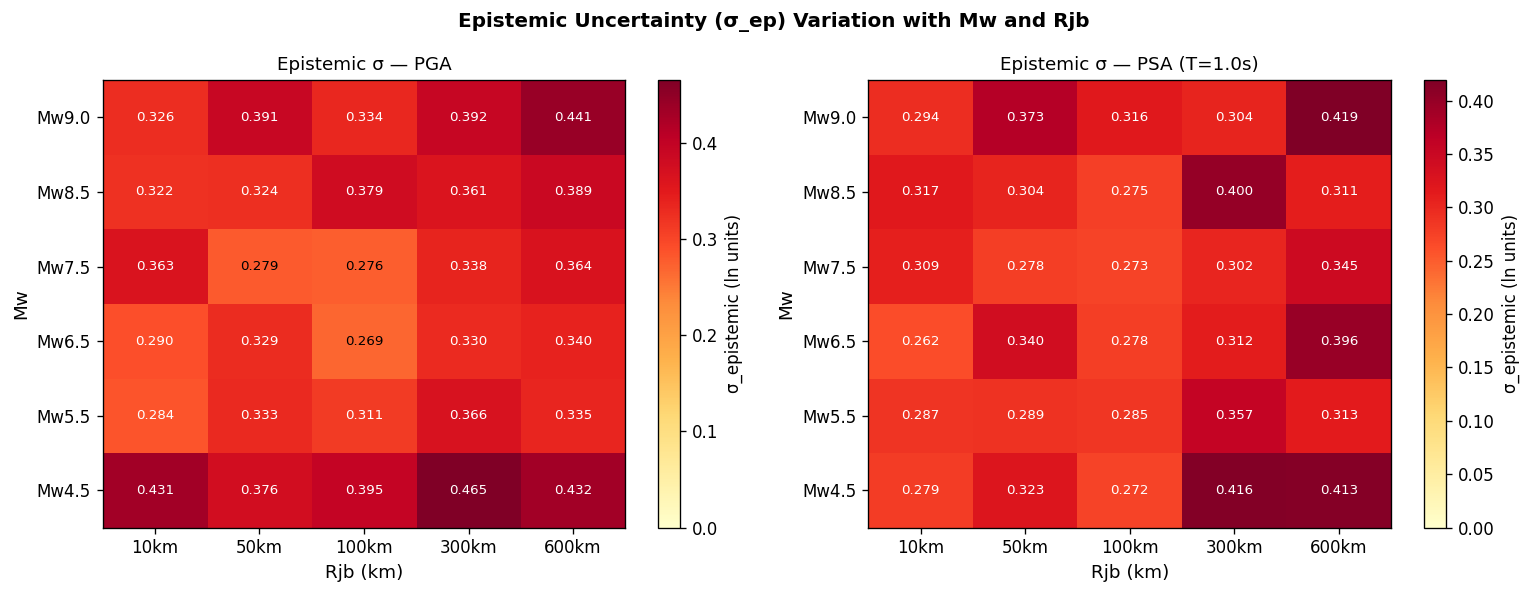

Saved: bnn_fig_epistemic_grid.png


In [24]:
Mw_grid  = np.array([4.5, 5.5, 6.5, 7.5, 8.5, 9.0])
Rjb_grid = np.array([10, 50, 100, 300, 600])
pi_1s    = get_out_idx(1.0)
pi_pga   = 105

print("Computing epistemic uncertainty grid (Mw x Rjb)...")
ep_grid_pga = np.zeros((len(Mw_grid), len(Rjb_grid)))
ep_grid_1s  = np.zeros((len(Mw_grid), len(Rjb_grid)))
N_EP = 50

for i, mw in enumerate(Mw_grid):
    for j, rjb in enumerate(Rjb_grid):
        X_sc = scaler_X_bnn.transform([[mw, rjb, np.log(max(rjb,0.01)),
                                          np.log(760), 30, 1]]).astype(np.float32)
        preds_full = np.stack([model_bnn(X_sc, training=True).numpy() for _ in range(N_EP)], axis=0)
        preds_mu   = np.stack([scaler_Y_bnn.inverse_transform(preds_full[k, :, :108]) for k in range(N_EP)], axis=0)
        ep_grid_pga[i, j] = preds_mu[:, 0, pi_pga].std()
        ep_grid_1s[i, j]  = preds_mu[:, 0, pi_1s].std()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Epistemic Uncertainty (σ_ep) Variation with Mw and Rjb', fontsize=12, fontweight='bold')

for ax, grid, title in zip(axes, [ep_grid_pga, ep_grid_1s], ['PGA', 'PSA (T=1.0s)']):
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='YlOrRd',
                   vmin=0, vmax=grid.max())
    ax.set_xticks(range(len(Rjb_grid))); ax.set_xticklabels([f'{r}km' for r in Rjb_grid])
    ax.set_yticks(range(len(Mw_grid)));  ax.set_yticklabels([f'Mw{m}' for m in Mw_grid])
    ax.set_xlabel('Rjb (km)', fontsize=11); ax.set_ylabel('Mw', fontsize=11)
    ax.set_title(f'Epistemic σ — {title}', fontsize=11)
    plt.colorbar(im, ax=ax, label='σ_epistemic (ln units)')
    for i in range(len(Mw_grid)):
        for j in range(len(Rjb_grid)):
            ax.text(j, i, f'{grid[i,j]:.3f}', ha='center', va='center',
                    fontsize=8, color='k' if grid[i,j] < grid.max()*0.6 else 'w')

plt.tight_layout()
plt.savefig('bnn_fig_epistemic_grid.png')
plt.show()
print("Saved: bnn_fig_epistemic_grid.png")


## Cell 25 — ANN vs BNN Comprehensive Comparison (Updated)

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  ANN vs BNN Performance Comparison (Improved BNN)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
Period  r² (ANN)  r² (BNN)  MSE (ANN)  MSE (BNN)  σ_al/resid (ANN)  σ_al/resid (BNN)  σ_al/learned (BNN)  σ_ep (BNN)  σ_tot (BNN)
 0.01s    0.8835    0.8186     0.6812     1.1266            0.8252            1.0337              1.0755      0.3390       1.1276
 0.05s    0.8711    0.8058     0.7849     1.1900            0.8858            1.0863              1.1597      0.3234       1.2039
  0.1s    0.8559    0.7858     0.9351     1.4114            0.9670            1.1823              1.2322      0.3771       1.2886
  0.2s    0.8676    0.8086     0.8461     1.2416            0.9198            1.1079              1.1901      0.3416       1.2382
  0.5s    0.8904    0.8403     0.6310     0.9549            0.7941           

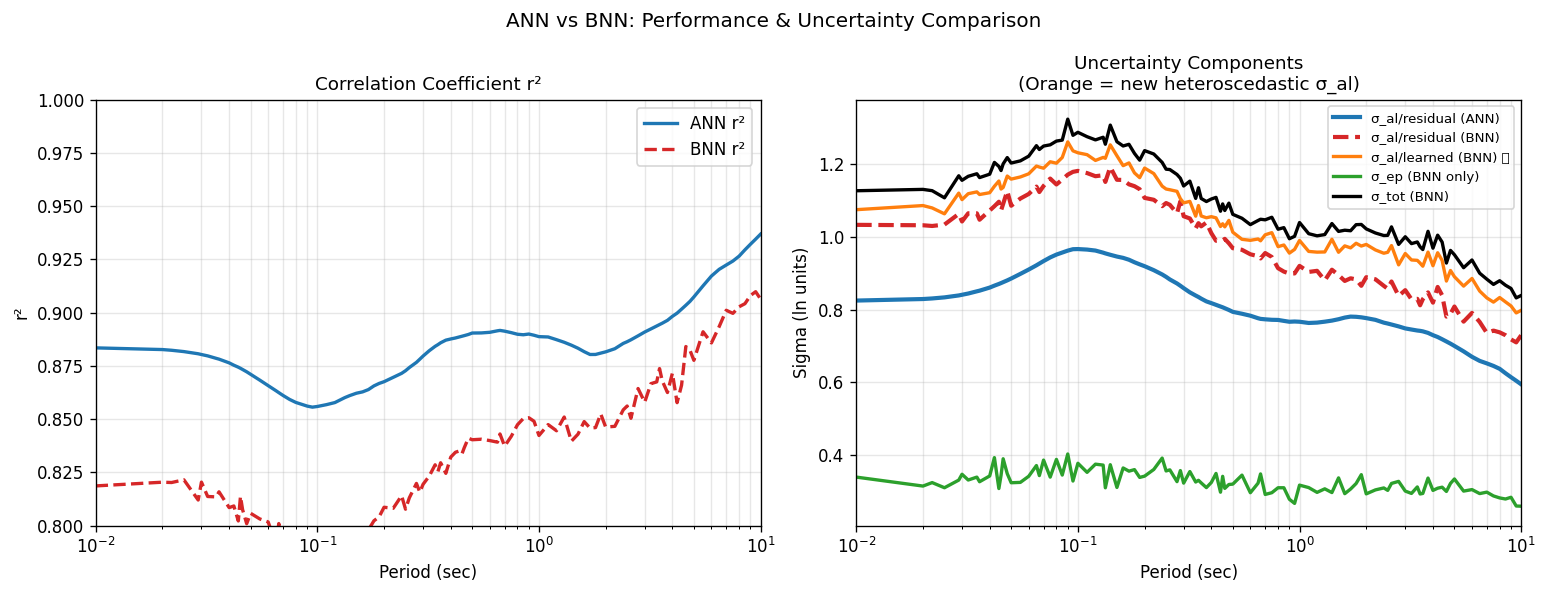

In [25]:
SEL_P = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 0]
rows = []
for sp in SEL_P:
    i   = get_out_idx(sp)
    yt  = Y_true_log[:, i]
    ya  = Y_ann_pred_log[:, i]
    yb  = Y_bnn_pred_log[:, i]
    r2a = np.corrcoef(yt, ya)[0,1]**2
    r2b = np.corrcoef(yt, yb)[0,1]**2
    mse_a = np.mean((yt-ya)**2)
    mse_b = np.mean((yt-yb)**2)
    label = 'PGA' if sp==0 else f'{sp}s'
    rows.append({
        'Period'     : label,
        'r² (ANN)'   : round(r2a,4),
        'r² (BNN)'   : round(r2b,4),
        'MSE (ANN)'  : round(mse_a,4),
        'MSE (BNN)'  : round(mse_b,4),
        'σ_al/resid (ANN)': round(me_ann[i]['sigma'],4),
        'σ_al/resid (BNN)': round(me_bnn[i]['sigma'],4),
        'σ_al/learned (BNN)': round(float(sigma_al_learned[i]),4),
        'σ_ep (BNN)' : round(float(sigma_ep[i]),4) if i<108 else 0,
        'σ_tot (BNN)': round(float(np.sqrt(sigma_al_learned[i]**2 + sigma_ep[i]**2)),4) if i<108 else 0,
    })
df_compare = pd.DataFrame(rows)
print("═"*110)
print("  ANN vs BNN Performance Comparison (Improved BNN)")
print("═"*110)
print(df_compare.to_string(index=False))
df_compare.to_csv('bnn_comparison_table.csv', index=False)
print("\nSaved: bnn_comparison_table.csv")

# Visual comparison
T_arr2 = np.array(PERIOD_VALUES)
r2_ann = [np.corrcoef(Y_true_log[:,i], Y_ann_pred_log[:,i])[0,1]**2 for i in range(105)]
r2_bnn = [np.corrcoef(Y_true_log[:,i], Y_bnn_pred_log[:,i])[0,1]**2 for i in range(105)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ANN vs BNN: Performance & Uncertainty Comparison', fontsize=12)

ax = axes[0]
ax.semilogx(T_arr2, r2_ann, color='#1f77b4', lw=2.0, label='ANN r²')
ax.semilogx(T_arr2, r2_bnn, color='#d62728', lw=2.0, ls='--', label='BNN r²')
ax.set_xlabel('Period (sec)'); ax.set_ylabel('r²')
ax.set_title('Correlation Coefficient r²'); ax.legend()
ax.grid(True, which='both', alpha=0.3); ax.set_xlim(0.01, 10); ax.set_ylim(0.8, 1.0)

ax = axes[1]
ax.semilogx(T_arr2, sig_ann,              color='#1f77b4', lw=2.5, label='σ_al/residual (ANN)')
ax.semilogx(T_arr2, sig_bnn,              color='#d62728', lw=2.5, ls='--', label='σ_al/residual (BNN)')
ax.semilogx(T_arr2, sigma_al_learned[:105], color='#ff7f0e', lw=2.0, ls='-', label='σ_al/learned (BNN) ⭐')
ax.semilogx(T_arr2, sigma_ep[:105],        color='#2ca02c', lw=2.0, label='σ_ep (BNN only)')
ax.semilogx(T_arr2, np.sqrt(sigma_al_learned[:105]**2 + sigma_ep[:105]**2),
            color='k', lw=2.0, label='σ_tot (BNN)')
ax.set_xlabel('Period (sec)'); ax.set_ylabel('Sigma (ln units)')
ax.set_title('Uncertainty Components\n(Orange = new heteroscedastic σ_al)'); ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3); ax.set_xlim(0.01, 10)

plt.tight_layout()
plt.savefig('bnn_fig_ann_vs_bnn_comparison.png')
plt.show()


## Cell 26 — Save Model, Scalers & Generate Summary

In [26]:
model_bnn.save_weights('bnn_gmpe.weights.h5')
model_ann.save('ann_gmpe_comparison.keras')

with open('scaler_X_bnn.pkl','wb') as f: pickle.dump(scaler_X_bnn, f)
with open('scaler_Y_bnn.pkl','wb') as f: pickle.dump(scaler_Y_bnn, f)
with open('scaler_X_ann.pkl','wb') as f: pickle.dump(scaler_X_ann, f)
with open('scaler_Y_ann.pkl','wb') as f: pickle.dump(scaler_Y_ann, f)

np.save('bnn_sigma_epistemic.npy',      sigma_ep)
np.save('bnn_sigma_aleatory_learned.npy', sigma_al_learned)
np.save('bnn_sigma_aleatory_residual.npy', sig_bnn)
np.save('bnn_ensemble_sample.npy',      ensemble_preds_log[:20])

print("=" * 65)
print("  IMPROVED BNN GMPE — Final Summary")
print("=" * 65)
print(f"  Architecture     : 6 → 12 [ELU] → [108 mu | 108 log_sigma]")
print(f"  Loss             : Gaussian NLL (heteroscedastic)")
print(f"  KL annealing     : beta 0→1 over warmup_epochs=150")
print(f"  Training records : {len(X_bnn_tr)}")
print(f"  Test records     : {len(X_bnn_te)}")
print(f"  Ensemble size    : {N_ENSEMBLE}")
print()
print(f"  Aleatory σ (learned, BNN): {sigma_al_learned[:105].min():.3f} – {sigma_al_learned[:105].max():.3f} ln")
print(f"  Aleatory σ (residual,BNN): {sig_bnn.min():.3f} – {sig_bnn.max():.3f} ln")
print(f"  Epistemic σ              : {sigma_ep[:105].min():.3f} – {sigma_ep[:105].max():.3f} ln")
print(f"  Total σ                  : {np.sqrt(sigma_al_learned[:105]**2+sigma_ep[:105]**2).min():.3f} – "
      f"{np.sqrt(sigma_al_learned[:105]**2+sigma_ep[:105]**2).max():.3f} ln")
print(f"  Calibration PICP (90%)   : {mean_picp:.3f}  (ideal=0.90)")
print(f"  Optimal temperature T*   : {T_optimal:.3f}")
print()
print("  HOW TO RELOAD AND PREDICT:")
print("  model_bnn = build_bnn(); model_bnn.load_weights('bnn_gmpe.weights.h5')")
print("  out = model_bnn(X_sc, training=True).numpy()  # (n, 216)")
print("  mu       = scaler_Y_bnn.inverse_transform(out[:, :108])   # ln space")
print("  sigma_al = softplus(out[:, 108:]) / Y_SCALE_FACTOR        # ln space")
print()
saved = [
    'bnn_gmpe.weights.h5', 'ann_gmpe_comparison.keras',
    'scaler_X_bnn.pkl', 'scaler_Y_bnn.pkl',
    'bnn_sigma_epistemic.npy', 'bnn_sigma_aleatory_learned.npy',
    'bnn_sigma_aleatory_residual.npy', 'bnn_comparison_table.csv',
    'bnn_fig_training_history.png', 'bnn_fig11_scatter.png',
    'bnn_fig17_std_deviation.png', 'bnn_fig20_uncertainty.png',
    'bnn_fig18_ensemble.png', 'bnn_fig14_residuals.png',
    'bnn_fig5_sa_vs_mw.png', 'bnn_fig6_sa_vs_rjb.png',
    'bnn_fig7_spectra_depth.png', 'bnn_fig_epistemic_grid.png',
    'bnn_fig_ann_vs_bnn_comparison.png', 'bnn_fig_calibration.png',
]
for f in saved:
    print(f"    ✓  {f}")


  IMPROVED BNN GMPE — Final Summary
  Architecture     : 6 → 12 [ELU] → [108 mu | 108 log_sigma]
  Loss             : Gaussian NLL (heteroscedastic)
  KL annealing     : beta 0→1 over warmup_epochs=150
  Training records : 6234
  Test records     : 2673
  Ensemble size    : 100

  Aleatory σ (learned, BNN): 0.791 – 1.262 ln
  Aleatory σ (residual,BNN): 0.710 – 1.193 ln
  Epistemic σ              : 0.259 – 0.403 ln
  Total σ                  : 0.833 – 1.325 ln
  Calibration PICP (90%)   : 0.932  (ideal=0.90)
  Optimal temperature T*   : 0.857

  HOW TO RELOAD AND PREDICT:
  model_bnn = build_bnn(); model_bnn.load_weights('bnn_gmpe.weights.h5')
  out = model_bnn(X_sc, training=True).numpy()  # (n, 216)
  mu       = scaler_Y_bnn.inverse_transform(out[:, :108])   # ln space
  sigma_al = softplus(out[:, 108:]) / Y_SCALE_FACTOR        # ln space

    ✓  bnn_gmpe.weights.h5
    ✓  ann_gmpe_comparison.keras
    ✓  scaler_X_bnn.pkl
    ✓  scaler_Y_bnn.pkl
    ✓  bnn_sigma_epistemic.npy
    ✓  b